In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit

In [2]:
df = pd.read_csv('/home/jaalzate/Files/training_df.csv')

In [3]:
df.partition.value_counts()

partition
train    4446
val       217
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   subject          4663 non-null   object 
 1   session          4663 non-null   object 
 2   image_t2         4663 non-null   object 
 3   image_dwi        4663 non-null   object 
 4   image_adc        4663 non-null   object 
 5   dep              4663 non-null   float64
 6   ED               4663 non-null   float64
 7   AF               54 non-null     float64
 8   TB               2223 non-null   float64
 9   TR               15 non-null     float64
 10  PSA              4271 non-null   float64
 11  VP               2907 non-null   float64
 12  PIR              1657 non-null   float64
 13  csPC             4663 non-null   float64
 14  F_nacimiento     4663 non-null   object 
 15  F_RM             4663 non-null   object 
 16  partition        4663 non-null   object 
 17  Derivative    

In [6]:

df['image_t2'] = df.apply(lambda row: '/mnt/ceib/datalake/FISABIO_datalake/p0052021' + row.image_t2 if row.partition == 'train' else '/mnt/ceib/datalake/FISABIO_datalake/p0042021' + row.image_t2, axis=1)
df['image_dwi'] = df.apply(lambda row: '/mnt/ceib/datalake/FISABIO_datalake/p0052021' + row.image_dwi if row.partition == 'train' else '/mnt/ceib/datalake/FISABIO_datalake/p0042021' + row.image_dwi, axis=1)
df['image_adc'] = df.apply(lambda row: '/mnt/ceib/datalake/FISABIO_datalake/p0052021' + row.image_adc if row.partition == 'train' else '/mnt/ceib/datalake/FISABIO_datalake/p0042021' + row.image_adc, axis=1)

In [7]:
#Check for columns where ED, AF, TB, TR, PSA, VP are not nan

df_not_na = df.dropna(subset=['ED', 'PSA', 'VP'])

In [8]:
df_not_na['PSA_density'] = df_not_na['PSA'] / df_not_na['VP']

/tmp/ipykernel_200399/569724825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_not_na['PSA_density'] = df_not_na['PSA'] / df_not_na['VP']


In [10]:
df_not_na

,subject,session,image_t2,image_dwi,image_adc,dep,ED,AF,TB,TR,PSA,VP,PIR,csPC,F_nacimiento,F_RM,partition,Derivative,VP_segmentation,PSA_density
3,sub-002299,ses-004352,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,82.0,NaN,2.0,NaN,0.014,38.88404,NaN,1.0,1935-05-07,2014-12-25,train,False,NaN,0.000360
4,sub-002299,ses-004352,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,82.0,NaN,2.0,NaN,0.014,38.88404,NaN,1.0,1935-05-07,2014-12-25,train,False,NaN,0.000360
5,sub-002299,ses-004352,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,82.0,NaN,2.0,NaN,0.014,38.88404,NaN,1.0,1935-05-07,2014-12-25,train,False,NaN,0.000360
8,sub-005249,ses-005651,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,60.0,NaN,5.0,NaN,5.150,44.92800,4.0,1.0,1948-12-08,2009-05-12,train,False,NaN,0.114628
9,sub-005249,ses-005651,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,60.0,NaN,5.0,NaN,5.150,44.92800,4.0,1.0,1948-12-08,2009-05-12,train,False,NaN,0.114628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4650,sub-000069,ses-000069,/mnt/ceib/datalake/FISABIO_datalake/p0042021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0042021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0042021/d...,7.0,65.0,NaN,1.0,NaN,13.010,134.18496,NaN,0.0,1948-05-27,2011-04-12,val,True,117.268066,0.096956
4652,sub-000092,ses-000092,/mnt/ceib/datalake/FISABIO_datalake/p0042021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0042021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0042021/d...,7.0,69.0,NaN,2.0,NaN,7.240,0.52000,NaN,0.0,1945-10-31,2014-10-02,val,True,149.049316,13.923077
4653,sub-000092,ses-000092,/mnt/ceib/datalake/FISABIO_datalake/p0042021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0042021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0042021/d...,7.0,69.0,NaN,2.0,NaN,7.240,0.52000,NaN,0.0,1945-10-31,2014-10-02,val,True,149.049316,13.923077
4656,sub-000120,ses-000120,/mnt/ceib/datalake/FISABIO_datalake/p0042021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0042021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0042021/d...,7.0,69.0,NaN,1.0,NaN,5.840,34.00000,4.0,0.0,1945-06-17,2014-09-24,val,True,37.376660,0.171765


In [11]:
df_not_na=df_not_na.reset_index(drop=True)
train_idx, test_idx = next(GroupShuffleSplit(test_size=.20, n_splits=2, random_state=42).split(df_not_na, groups=df_not_na['subject']))
df_not_na.loc[train_idx, 'partition'] = 'train'
df_not_na.loc[test_idx, 'partition'] = 'val'

In [12]:
df_not_na.partition.value_counts()

partition
train    2130
val       540
Name: count, dtype: int64

In [14]:
df_not_na[df_not_na.partition=='val'].csPC.value_counts()

csPC
1.0    301
0.0    239
Name: count, dtype: int64

In [17]:
df_not_na.to_csv('/home/jaalzate/Files/training_df_variables_not_na.csv', index=False)

In [18]:
df_not_na['csPC'].value_counts()

csPC
0.0    1404
1.0    1266
Name: count, dtype: int64

# Training Test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit,GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## Data Analysis

In [2]:
import seaborn as sns
import numpy as np
import os
import math

def create_prostate_cancer_visualizations(df, output_dir='.', variables=["ED", "PSA", "VP", "PSA_density"]):
    """
    Create a comprehensive set of visualizations for prostate cancer data analysis.
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame containing the columns: ED, PSA, VP, PSA_density, csPC
    output_dir : str, default='.'
        Directory to save the output visualization files
    variables : list, default=["ED", "PSA", "VP", "PSA_density"]
        List of variables to visualize
    
    Returns:
    --------
    None
    """
    import matplotlib.pyplot as plt
    
    # Ensure csPC is categorical
    df["csPC"] = df["csPC"].astype('category')

    # Set a more professional publication style
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans'],
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
        'figure.titlesize': 16
    })
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.2)
    
    # Calculate the number of rows and columns for subplots
    num_vars = len(variables)
    cols = min(2, num_vars)  # Maximum 2 columns
    rows = math.ceil(num_vars / cols)
    
    # 1. Histograms with better styling
    fig, axes = plt.subplots(rows, cols, figsize=(8*cols, 6*rows), dpi=100)
    
    # Make axes a 2D array even if there's only one row or one column
    if num_vars == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)
    
    axes = axes.flatten()
    palette = sns.color_palette("RdBu_r", 2)

    for i, var in enumerate(variables):
        if i < len(axes):
            ax = axes[i]
            sns.histplot(data=df, x=var, hue="csPC", kde=True, ax=ax, 
                        multiple="stack", palette=palette, alpha=0.7, element="step",
                        legend=(i == 0))
            ax.set_title(f'Distribution of {var} by csPC Status', fontweight='bold')
            ax.set_xlabel(f'{var}', fontweight='bold')
            ax.set_ylabel('Count', fontweight='bold')
            
            # Add vertical lines for the mean of each group
            for cspc, color in zip([0, 1], palette):
                mean_val = df[df.csPC == cspc][var].mean()
                ax.axvline(mean_val, color=color, linestyle='--', linewidth=2,
                        label=f'Mean (csPC={cspc}): {mean_val:.2f}')
                
            ax.legend(title="csPC Status", frameon=True, framealpha=0.9)
            sns.despine(ax=ax, left=True, bottom=True)
    
    # Hide unused subplots
    for i in range(num_vars, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle('Distribution of Clinical Variables by Prostate Cancer Status', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.savefig(os.path.join(output_dir, 'histograms_by_cspc.pdf'), dpi=500, bbox_inches='tight')
    plt.show()

    # 2. Boxplots with violin plots for better density visualization
    fig, axes = plt.subplots(rows, cols, figsize=(8*cols, 6*rows), dpi=100)
    
    # Make axes a 2D array even if there's only one row or one column
    if num_vars == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)
        
    axes = axes.flatten()

    for i, var in enumerate(variables):
        if i < len(axes):
            ax = axes[i]
            # Violin plot with boxplot overlay
            sns.violinplot(x="csPC", y=var, data=df, inner=None, 
                        cut=0, ax=ax, palette="RdBu_r", alpha=0.5)
            sns.boxplot(x="csPC", y=var, data=df, width=0.3, 
                    ax=ax, palette="RdBu_r", saturation=1)
            sns.stripplot(x="csPC", y=var, data=df, color="black", 
                        size=2, jitter=True, alpha=0.2, ax=ax)
            
            # Add statistical annotation
            means = df.groupby('csPC')[var].mean()
            for j, cspc in enumerate([0, 1]):
                ax.text(j, df[var].min(), f'Mean: {means[cspc]:.2f}', 
                        ha='center', fontweight='bold', color='darkblue', fontsize=10)
            
            ax.set_title(f'Distribution of {var} by csPC Status', fontweight='bold')
            ax.set_xlabel('Clinically Significant Prostate Cancer', fontweight='bold')
            ax.set_ylabel(var, fontweight='bold')
            ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
    
    # Hide unused subplots
    for i in range(num_vars, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle('Detailed Distribution Analysis of Clinical Variables', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.savefig(os.path.join(output_dir, 'boxplots_violins_by_cspc.pdf'), dpi=500, bbox_inches='tight')
    plt.show()

    # 3. Correlation matrix with custom styling
    plt.figure(figsize=(12, 10), dpi=100)
    # Create a mask for the upper triangle
    corr_matrix = df[variables + ["csPC"]].corr()
    mask = np.triu(np.ones_like(corr_matrix))
    # Custom colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap=cmap, linewidths=0.8, 
               mask=mask, square=True, cbar_kws={"shrink": .8}, vmin=-1, vmax=1,
               annot_kws={"size": 12, "weight": 'bold'})

    plt.title('Correlation Matrix of Clinical Variables', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'correlation_matrix.pdf'), dpi=500, bbox_inches='tight')
    plt.show()

    # 4. Correlation bar chart for variable importance relative to csPC
    plt.figure(figsize=(10, 7), dpi=100)
    corr_with_cspc = corr_matrix['csPC'].drop('csPC').sort_values(ascending=False)
    colors = ['#ff9999' if x < 0 else '#66b3ff' for x in corr_with_cspc]

    ax = sns.barplot(x=corr_with_cspc.values, y=corr_with_cspc.index, palette=colors, orient='h')
    plt.title('Correlation of Variables with csPC', fontsize=16, fontweight='bold')
    plt.xlabel('Pearson Correlation Coefficient', fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

    # Add correlation values
    for i, v in enumerate(corr_with_cspc):
        ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}', 
                va='center', ha='left' if v >= 0 else 'right', 
                fontweight='bold', color='black')

    sns.despine(left=True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'correlation_with_cspc.pdf'), dpi=500, bbox_inches='tight')
    plt.show()

    # 5. Pairplot with better styling
    pair_plot = sns.pairplot(
        df[variables + ["csPC"]], 
        hue="csPC",
        diag_kind="kde", 
        plot_kws={"s": 20, "alpha": 0.6},
        diag_kws={"alpha": 0.5, "linewidth": 2},
        palette="RdBu_r",
        corner=True  # Only show lower triangle
    )

    # Improve the appearance
    pair_plot.fig.suptitle("Relationships Between Clinical Variables", y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'pairplot_relationships.pdf'), dpi=500, bbox_inches='tight')
    plt.show()

    # 6. Feature density plots
    fig, axes = plt.subplots(rows, cols, figsize=(8*cols, 6*rows), dpi=100)
    
    # Make axes a 2D array even if there's only one row or one column
    if num_vars == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)
        
    axes = axes.flatten()

    for i, var in enumerate(variables):
        if i < len(axes):
            ax = axes[i]
            for j, cls in enumerate([0, 1]):
                subset = df[df.csPC == cls][var]
                sns.kdeplot(
                    subset, 
                    ax=ax, 
                    fill=True, 
                    common_norm=False,
                    alpha=0.5,
                    linewidth=2,
                    label=f'csPC={cls} (n={len(subset)})'
                )
            
            # Add vertical lines for median values
            for j, cls in enumerate([0, 1]):
                median = df[df.csPC == cls][var].median()
                ax.axvline(median, color=palette[j], linestyle='--', linewidth=2,
                        label=f'Median (csPC={cls}): {median:.2f}')
            
            ax.set_title(f'Density Distribution: {var}', fontweight='bold')
            ax.set_xlabel(var, fontweight='bold')
            ax.set_ylabel('Density', fontweight='bold')
            ax.legend(frameon=True, framealpha=0.9)
    
    # Hide unused subplots
    for i in range(num_vars, len(axes)):
        axes[i].set_visible(False)
        
    fig.suptitle('Density Comparison of Variables by csPC Status', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.savefig(os.path.join(output_dir, 'density_distributions.pdf'), dpi=500, bbox_inches='tight')
    plt.show()


In [3]:
# Cargar el archivo CSV
file_path = "/home/jaalzate/Files/training_df_variables_not_na.csv"
df = pd.read_csv(file_path)

# variables = ["ED", "PSA", "VP", "PSA_density", "csPC"]
variables = ["ED", "PSA", "VP", "PSA_density", "csPC","dep","PIR"]
df_filtered = df[variables].dropna()

lower_bound = df_filtered.quantile(0.01)
upper_bound = df_filtered.quantile(0.99)
df_cleaned = df_filtered[(df_filtered >= lower_bound) & (df_filtered <= upper_bound)].dropna()

In [4]:
df.columns

Index(['subject', 'session', 'image_t2', 'image_dwi', 'image_adc', 'dep', 'ED',
       'AF', 'TB', 'TR', 'PSA', 'VP', 'PIR', 'csPC', 'F_nacimiento', 'F_RM',
       'partition', 'Derivative', 'VP_segmentation', 'PSA_density'],
      dtype='object')

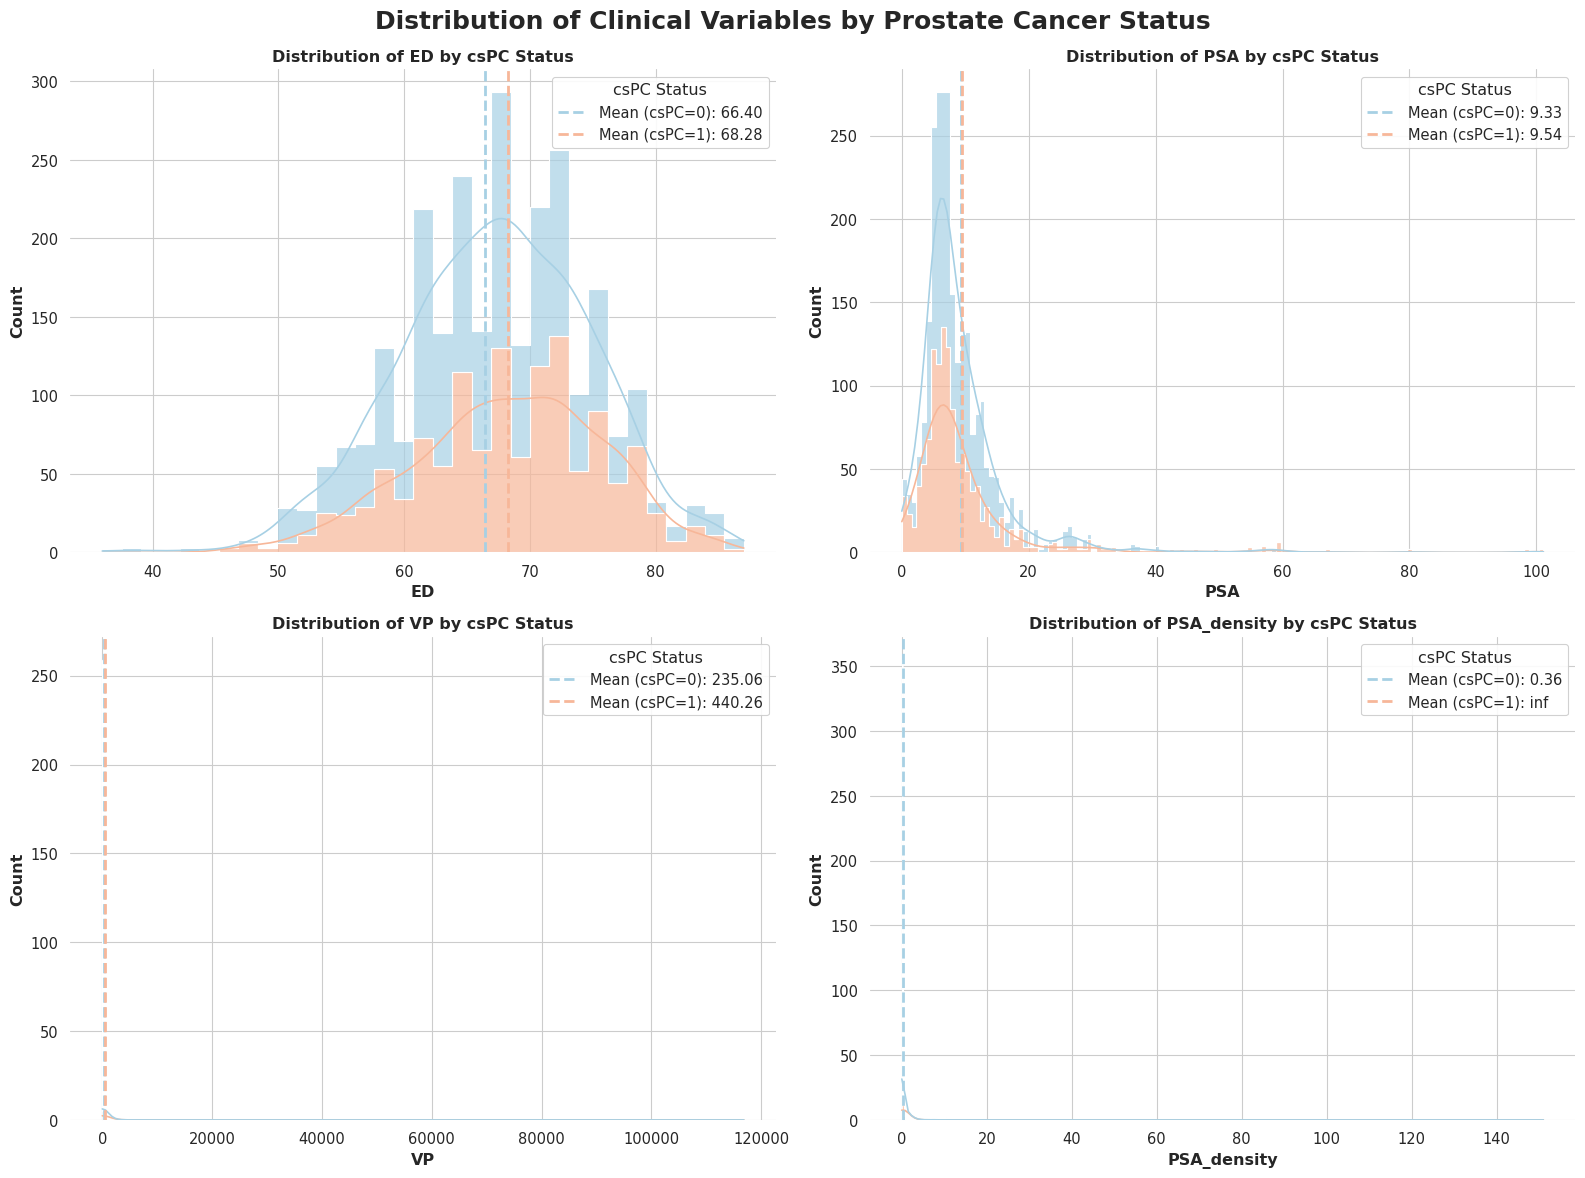

/tmp/ipykernel_73240/3633514940.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="csPC", y=var, data=df, inner=None,
/tmp/ipykernel_73240/3633514940.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="csPC", y=var, data=df, width=0.3,
/tmp/ipykernel_73240/3633514940.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('csPC')[var].mean()
/tmp/ipykernel_73240/3633514940.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after 

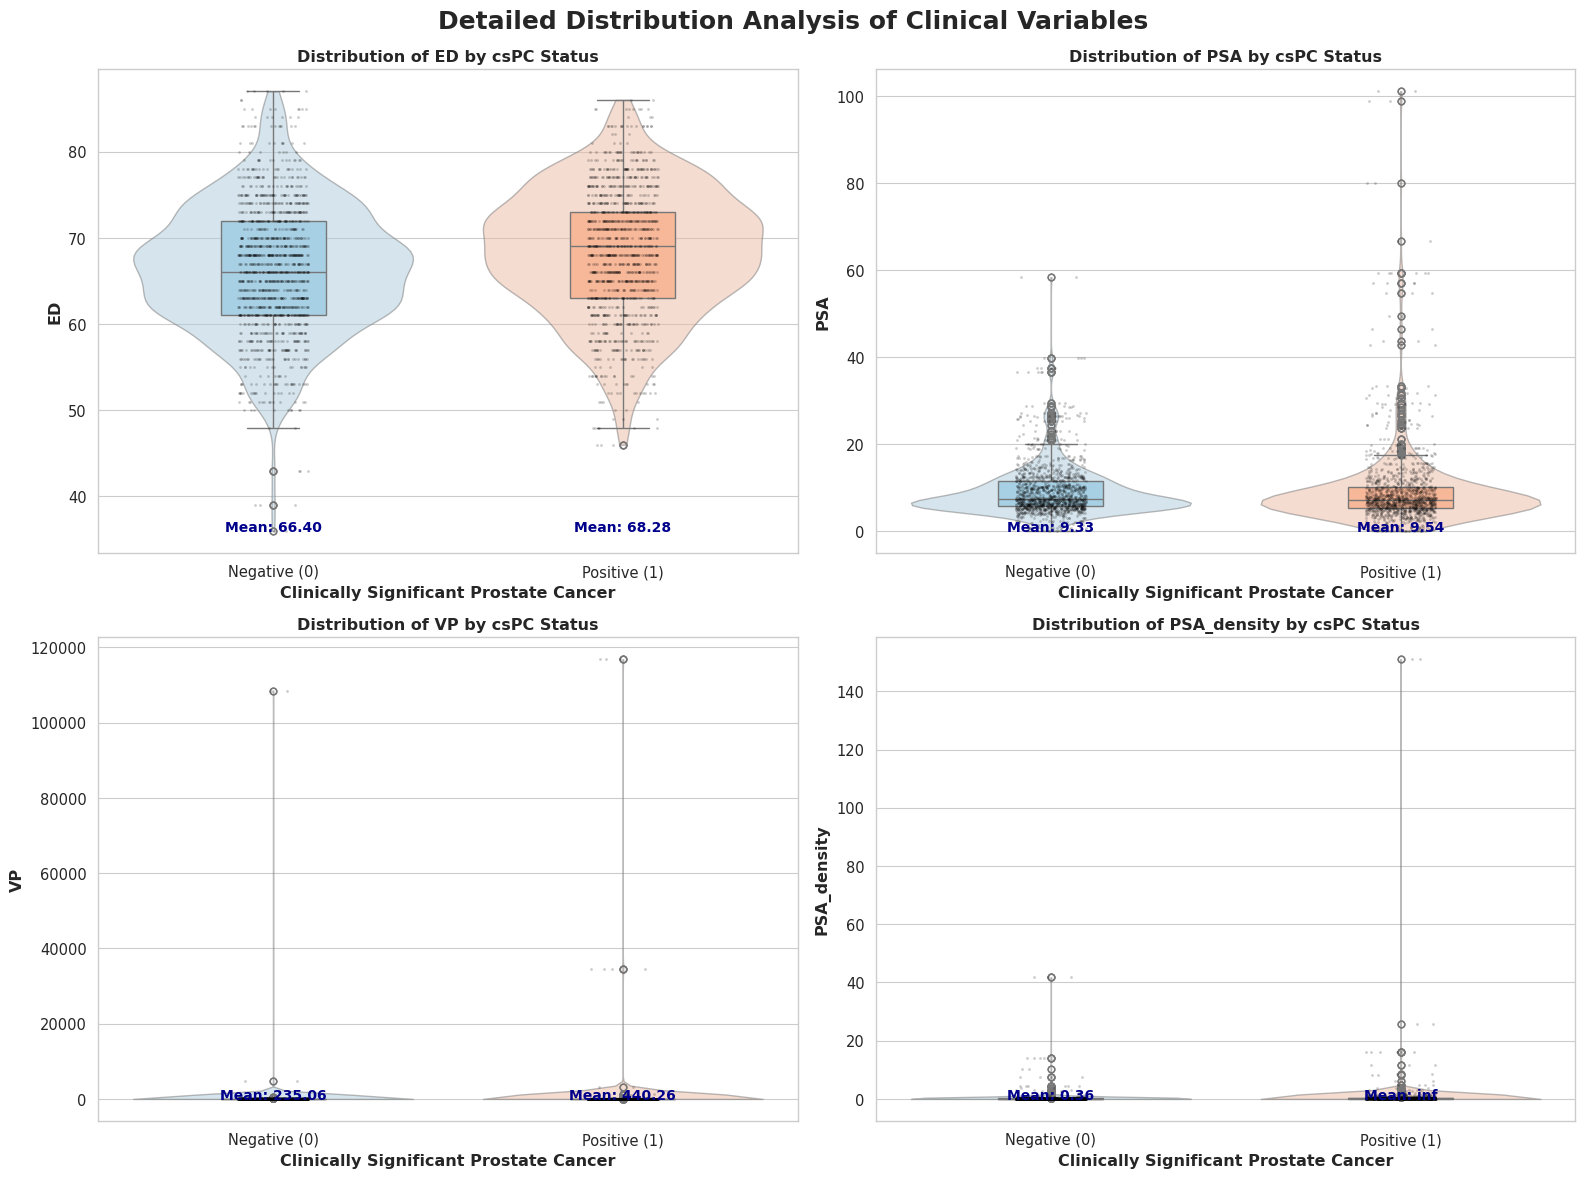

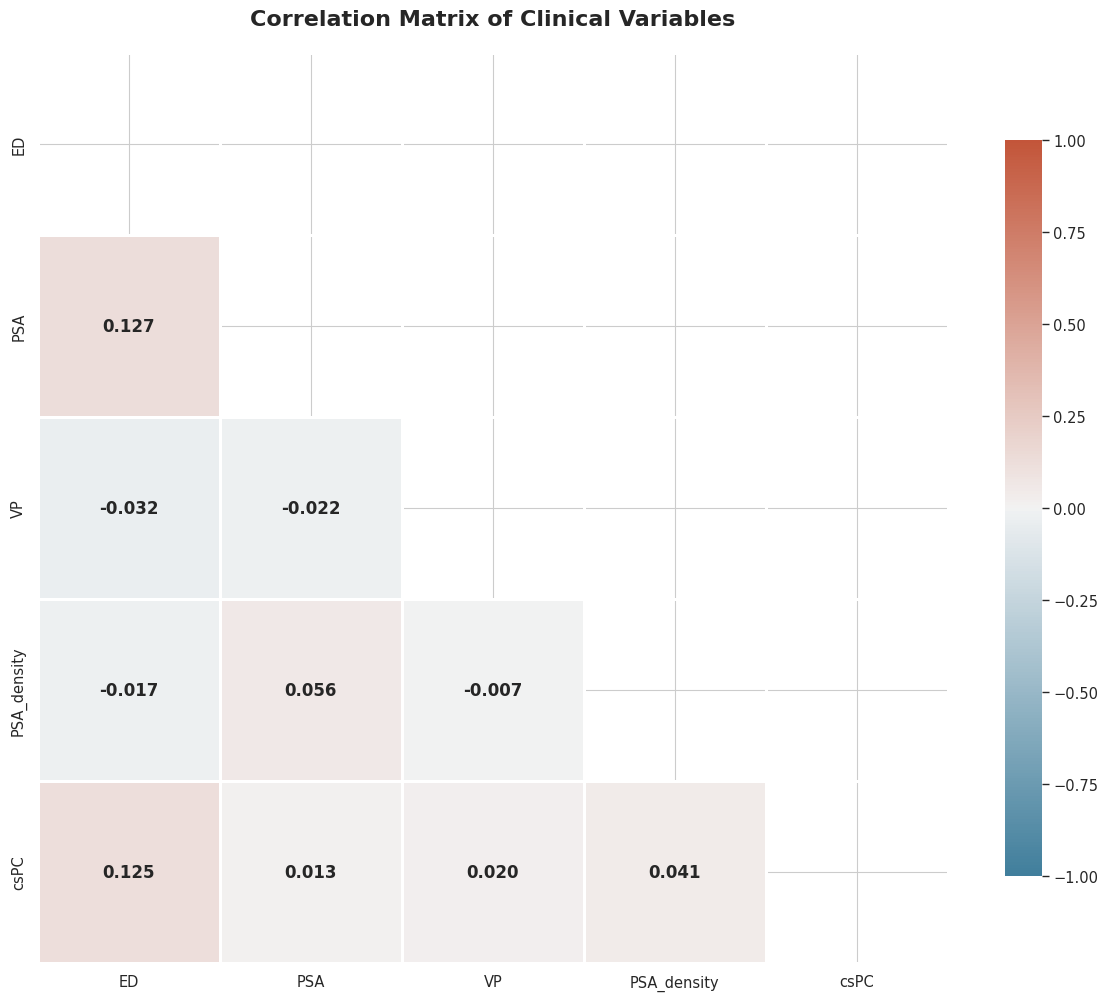

/tmp/ipykernel_73240/3633514940.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=corr_with_cspc.values, y=corr_with_cspc.index, palette=colors, orient='h')


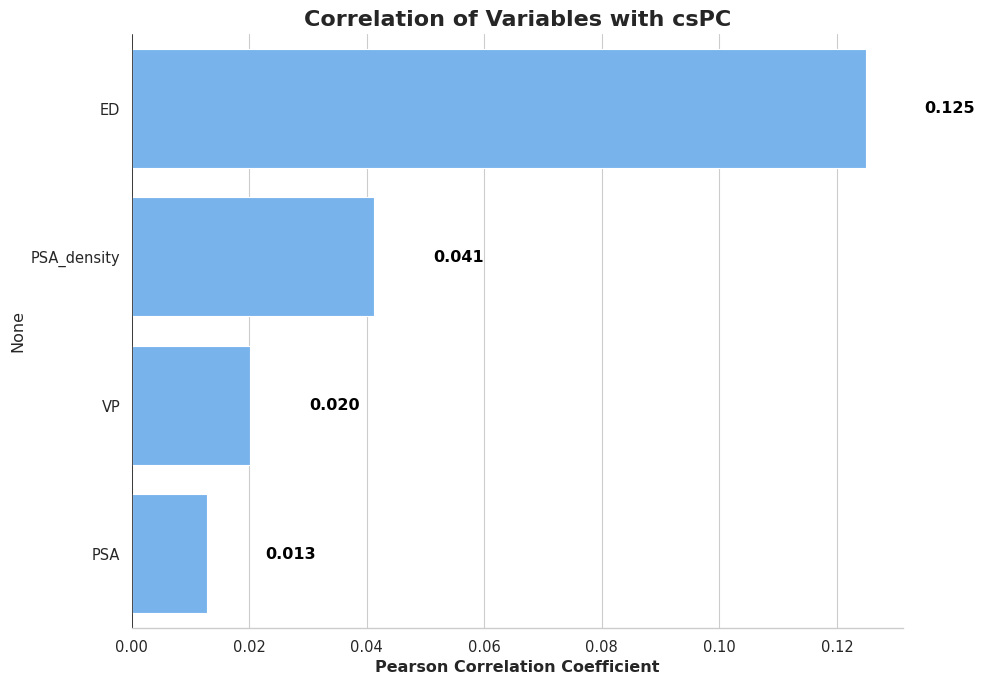

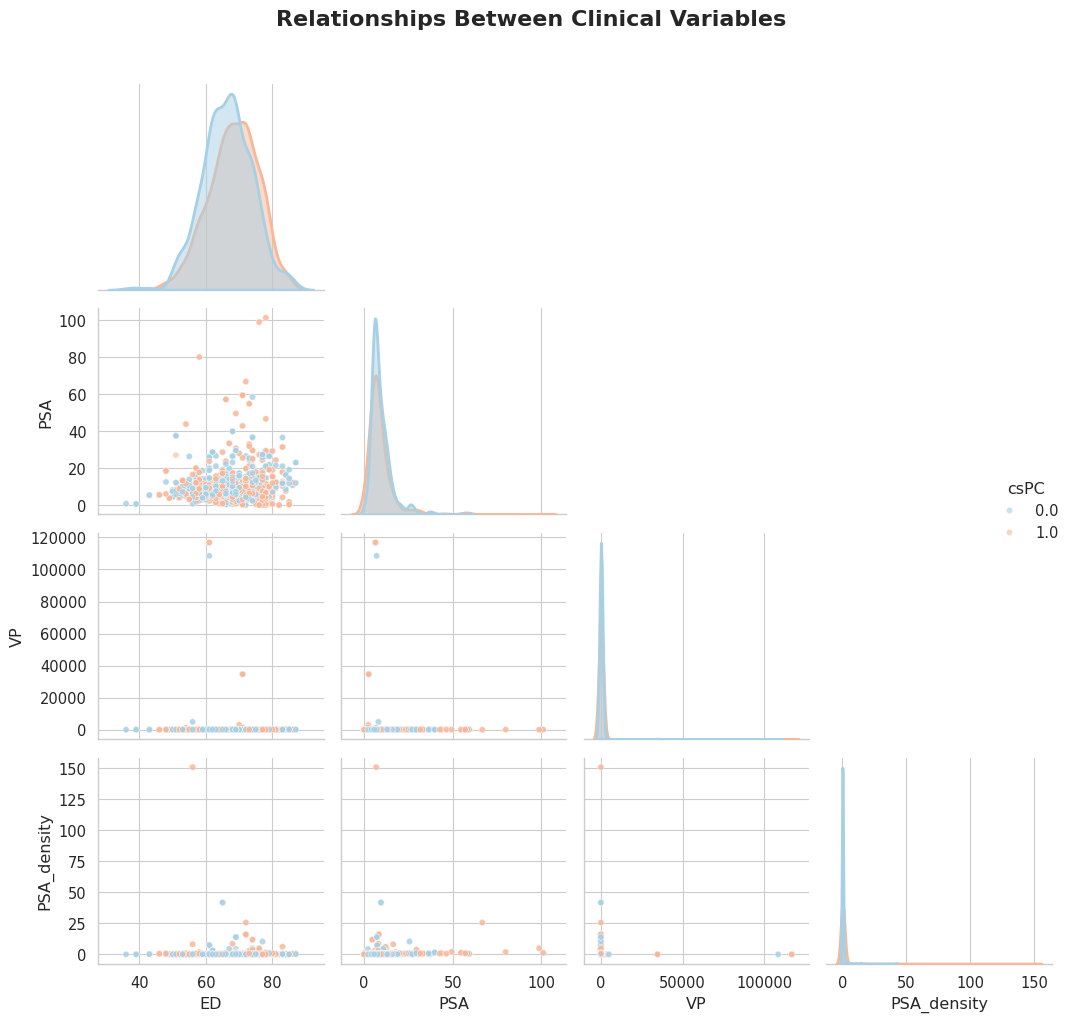

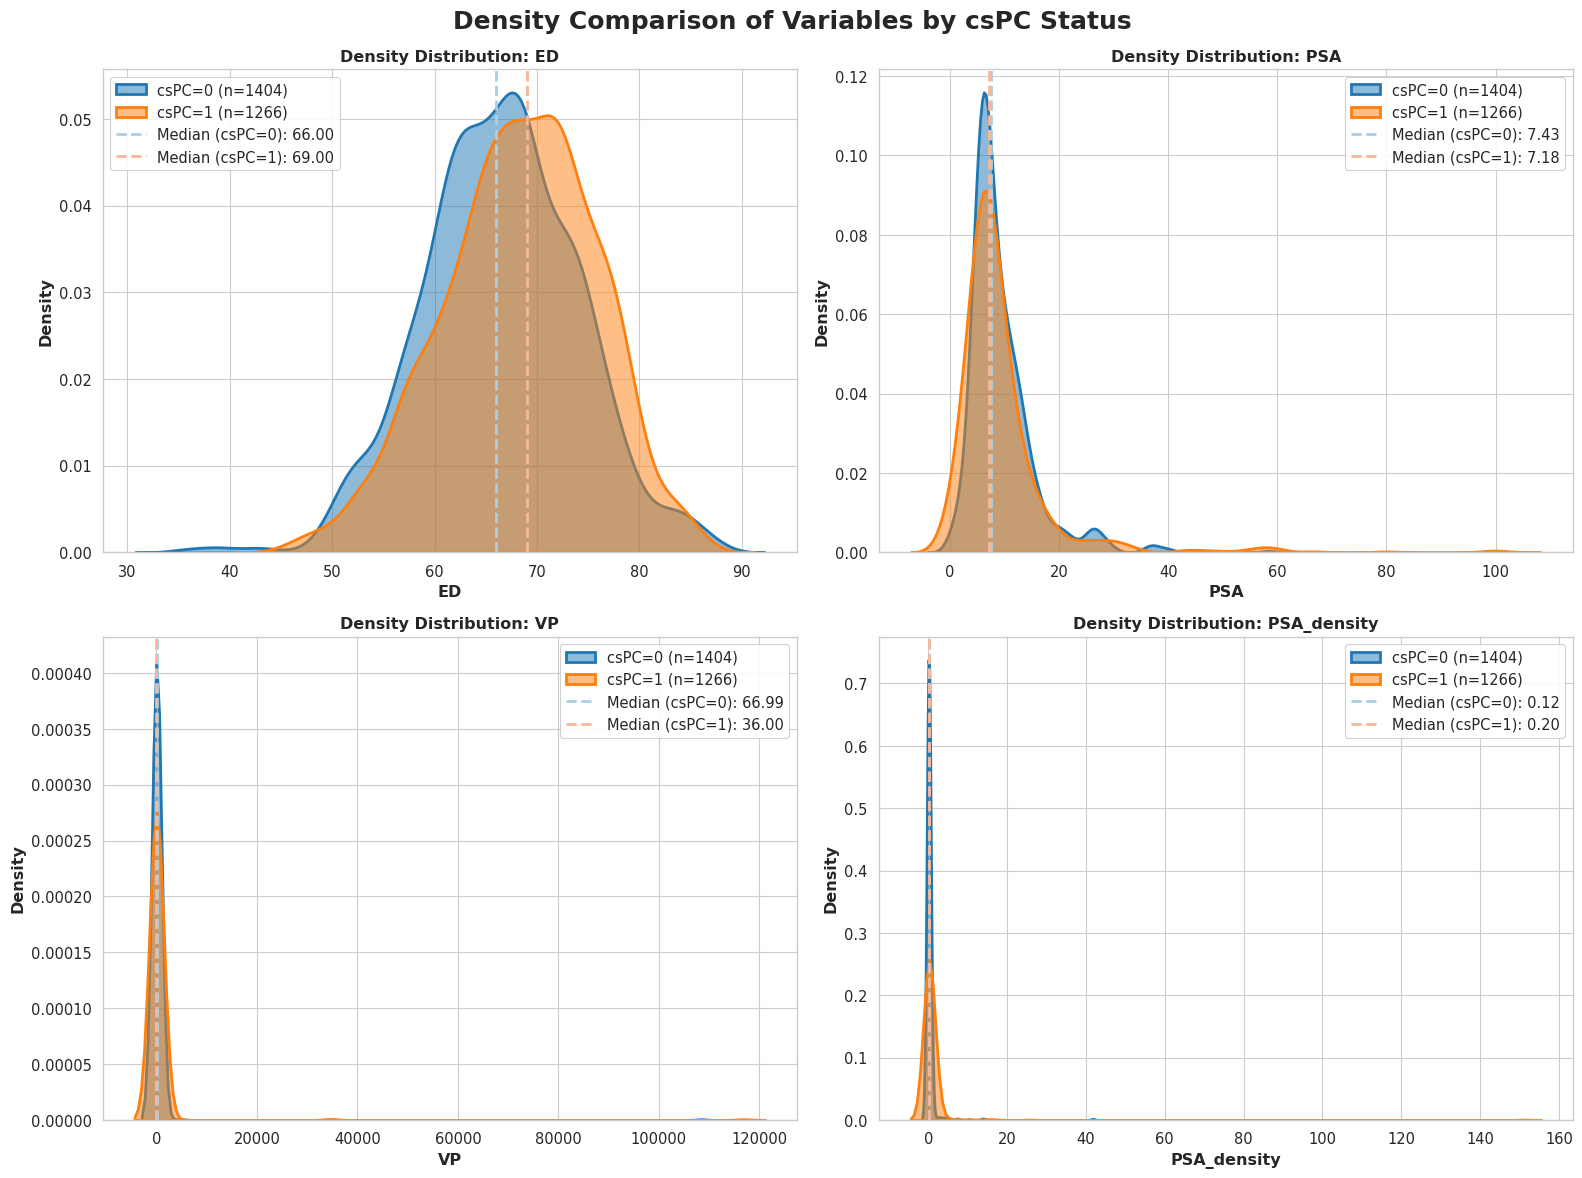

In [6]:
create_prostate_cancer_visualizations(df, output_dir='/home/jaalzate/Files', variables = ["ED", "PSA", "VP", "PSA_density"])

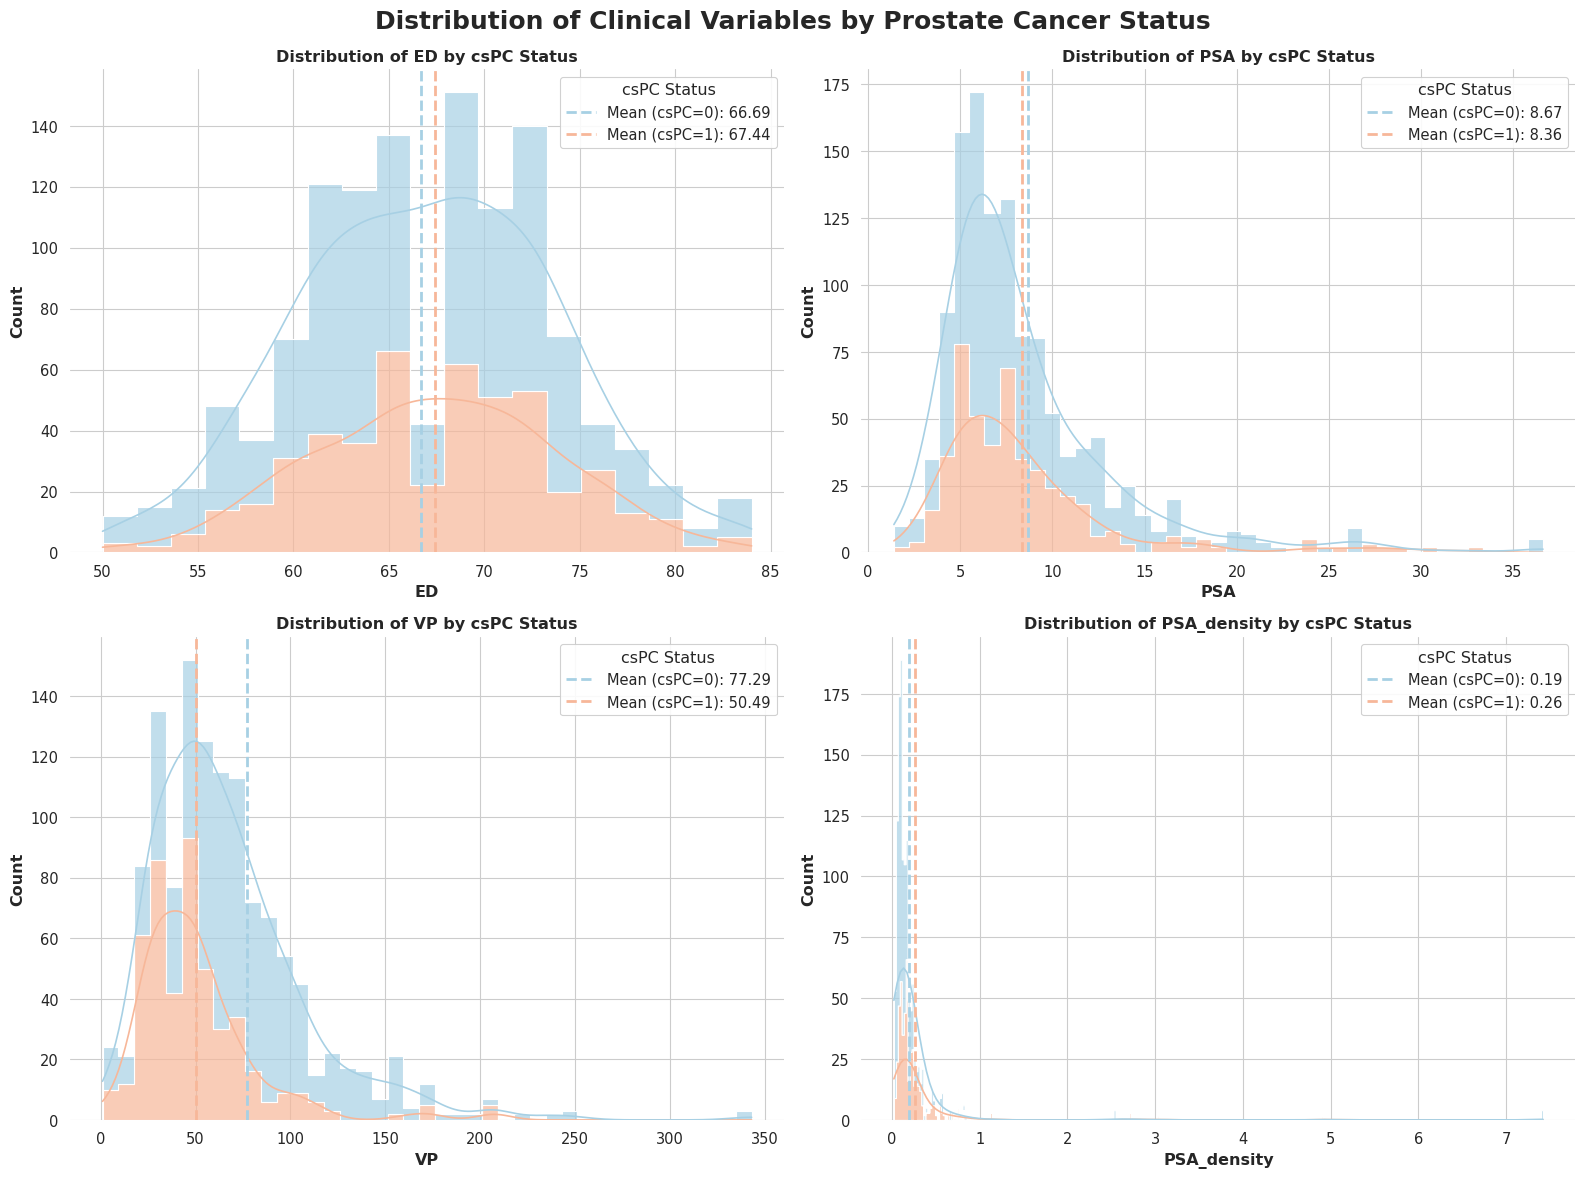

/tmp/ipykernel_73240/3633514940.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="csPC", y=var, data=df, inner=None,
/tmp/ipykernel_73240/3633514940.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="csPC", y=var, data=df, width=0.3,
/tmp/ipykernel_73240/3633514940.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('csPC')[var].mean()
/tmp/ipykernel_73240/3633514940.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after 

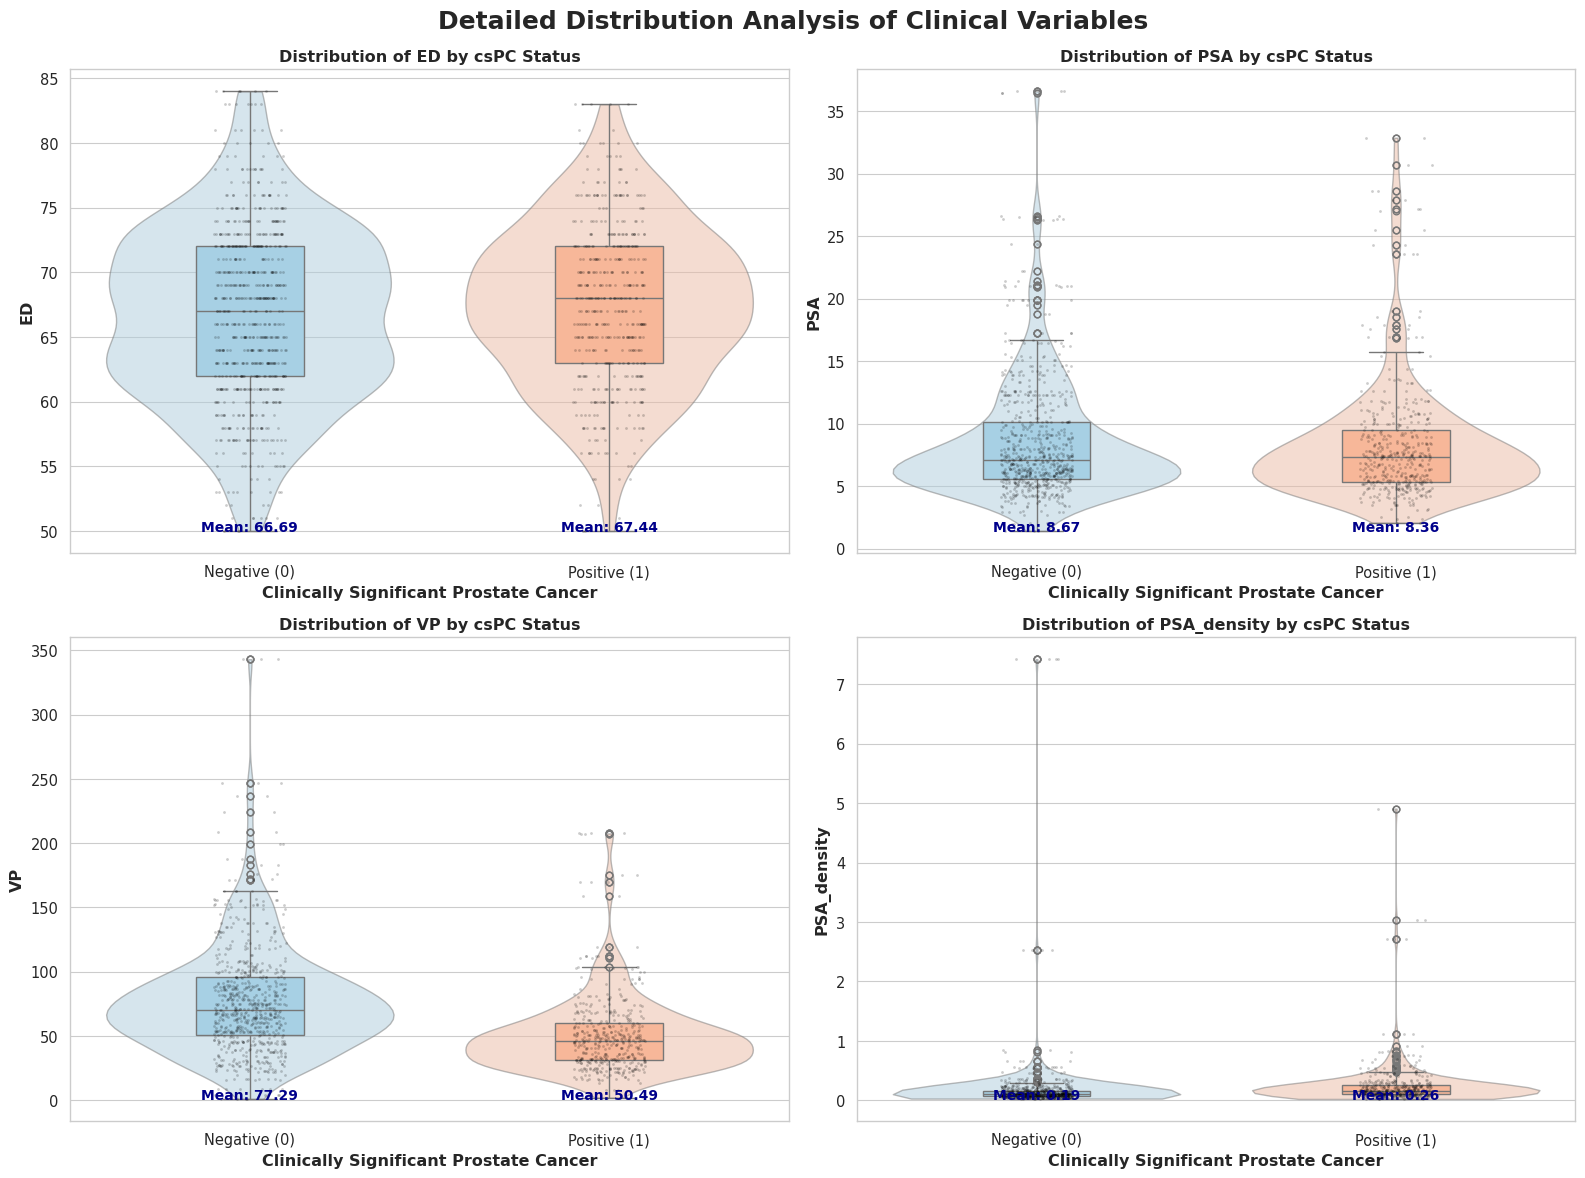

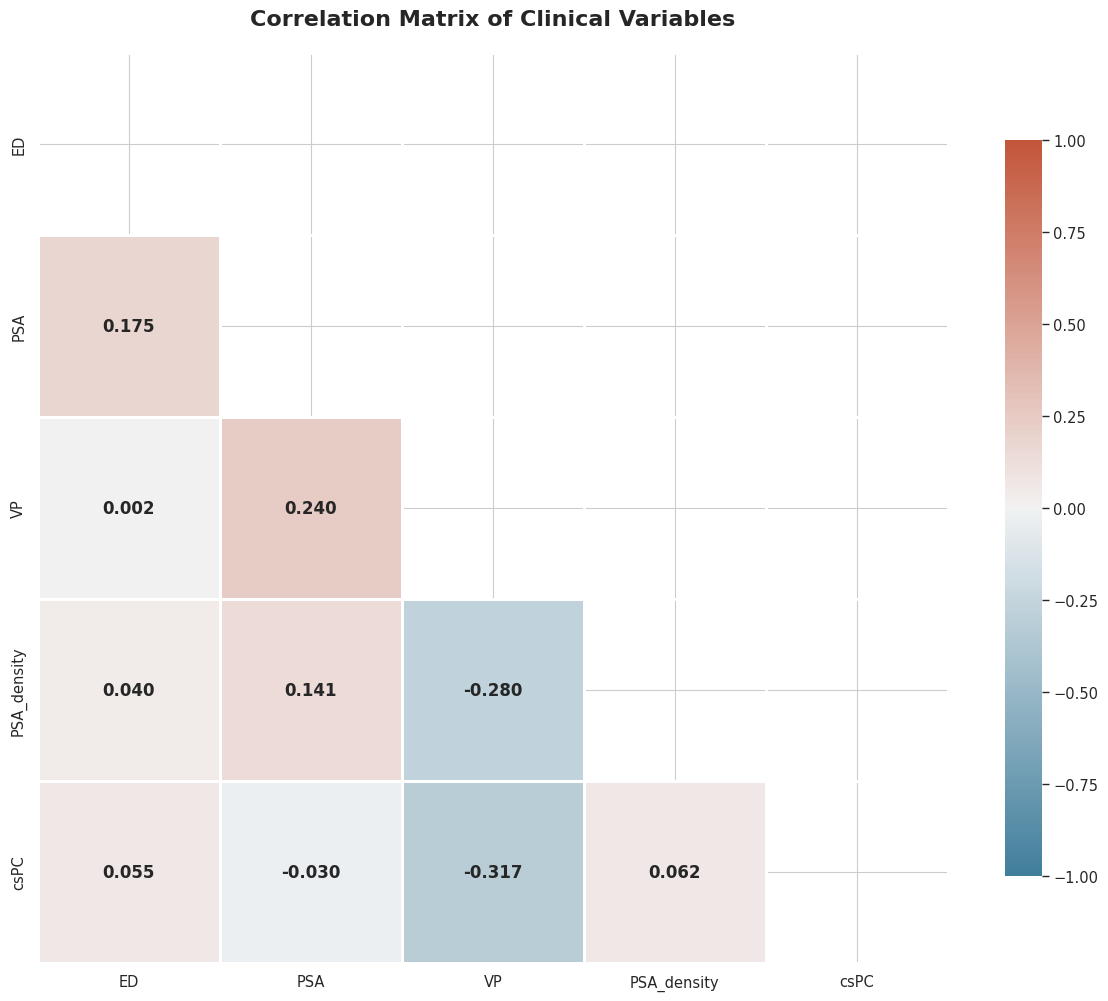

/tmp/ipykernel_73240/3633514940.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=corr_with_cspc.values, y=corr_with_cspc.index, palette=colors, orient='h')


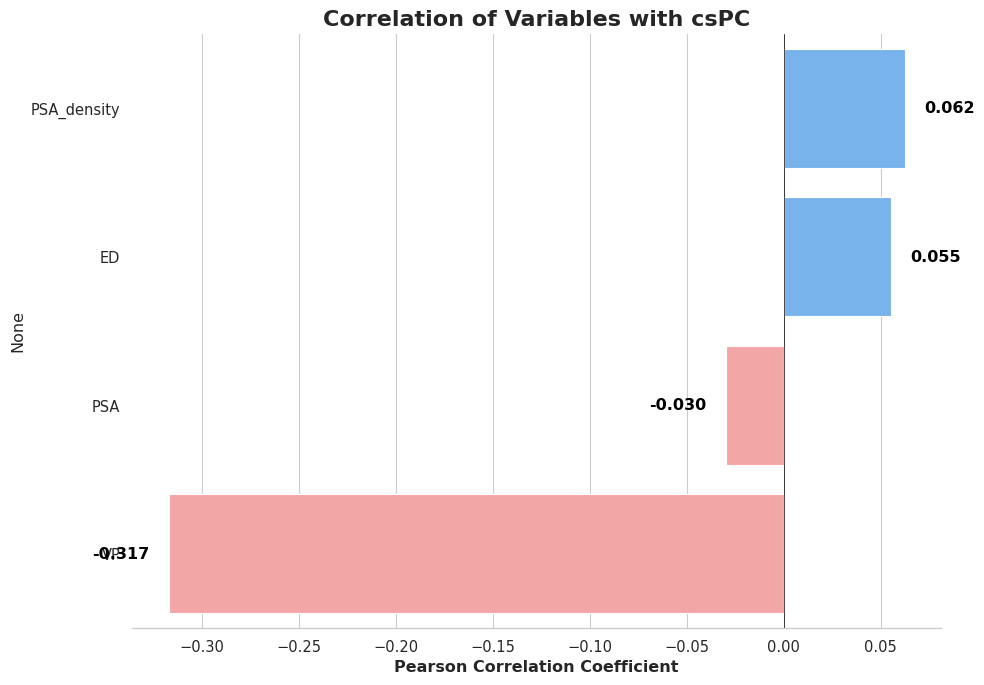

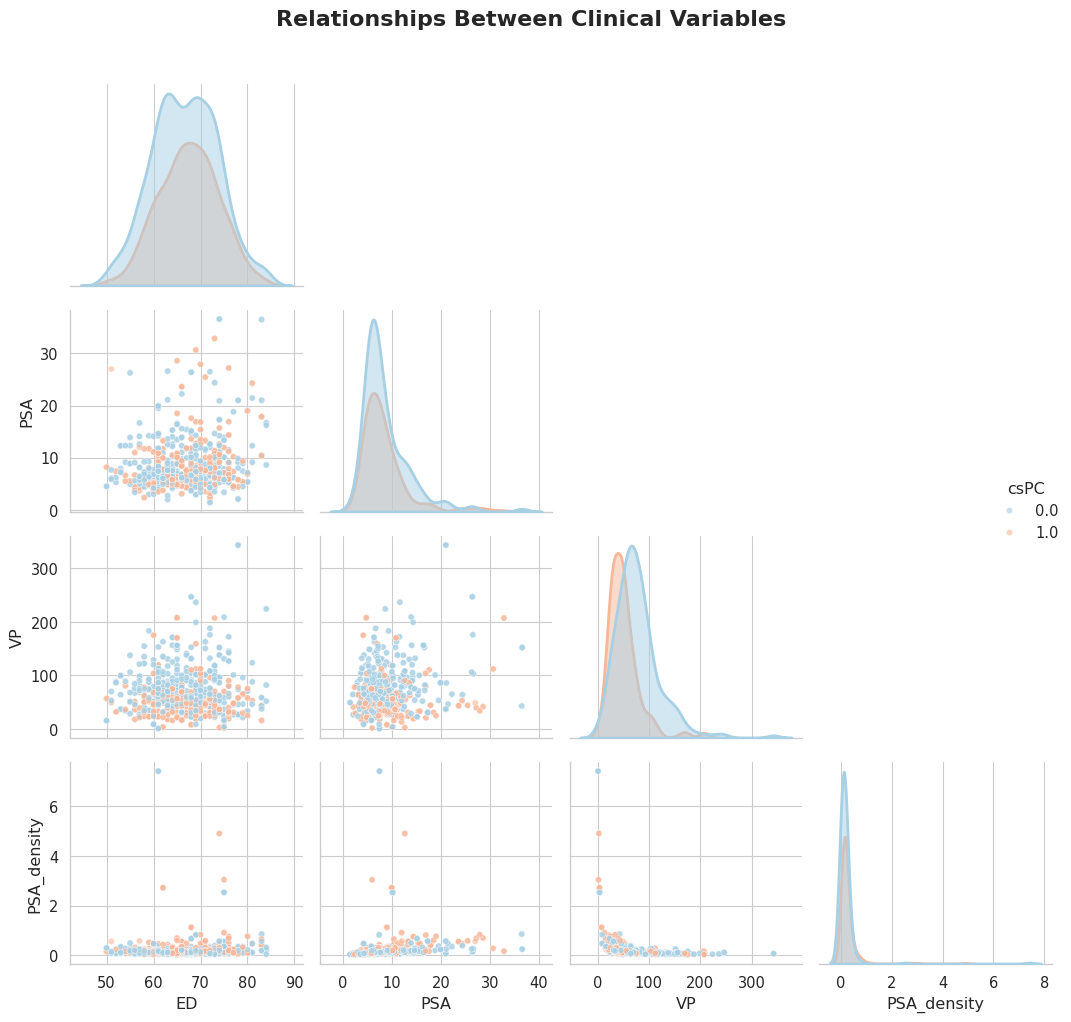

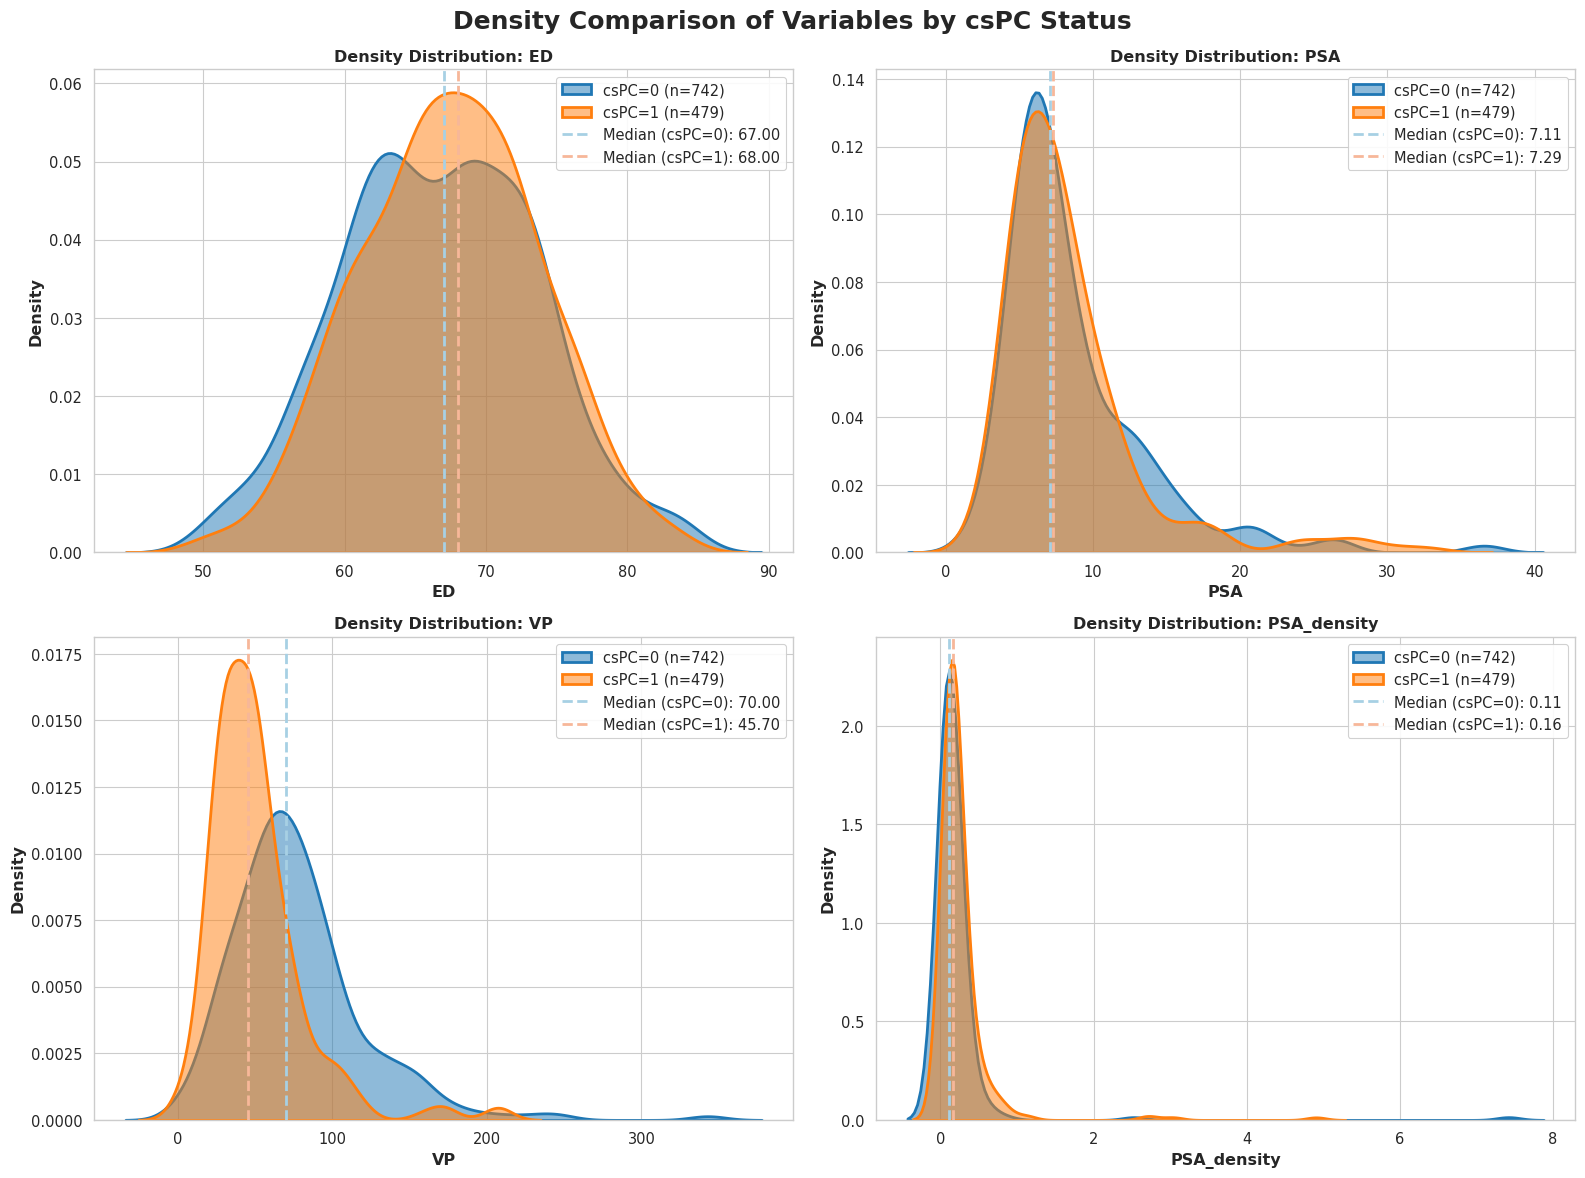

In [7]:
create_prostate_cancer_visualizations(df_cleaned, output_dir='/home/jaalzate/Files', variables = ["ED", "PSA", "VP", "PSA_density"])

In [8]:
df_cleaned.csPC.value_counts()

csPC
0.0    742
1.0    479
Name: count, dtype: int64

/tmp/ipykernel_173004/2969132506.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_cleaned, x="csPC", palette="Blues_d")


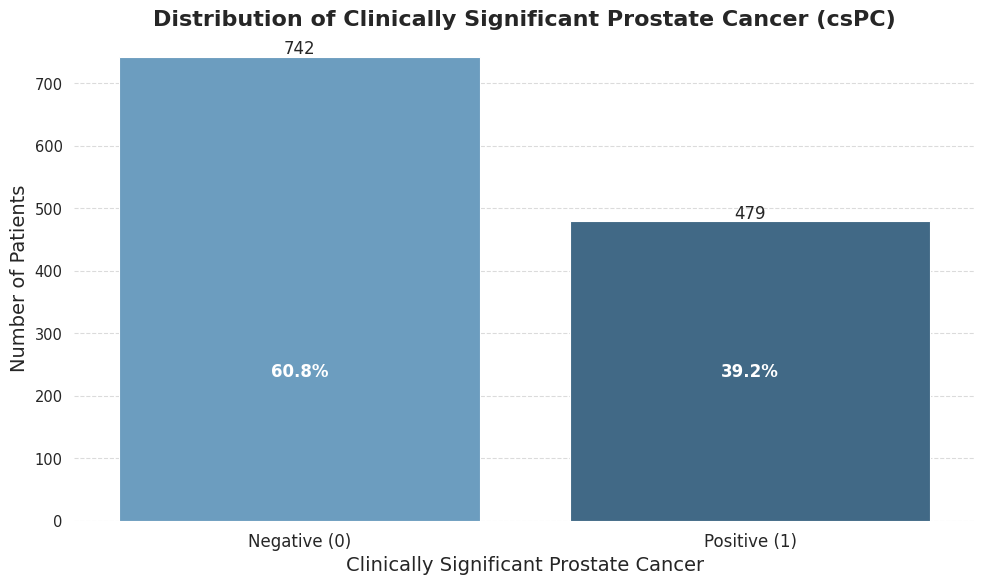

In [11]:
# Create a more professional visualization of csPC distribution
plt.figure(figsize=(10, 6))

# Plot the count with a nicer color palette
ax = sns.countplot(data=df_cleaned, x="csPC", palette="Blues_d")

# Add count labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 5,
            f'{int(height)}', 
            ha="center", fontsize=12)

# Enhance the plot with better styling
plt.title("Distribution of Clinically Significant Prostate Cancer (csPC)", fontsize=16, fontweight='bold')
plt.xlabel("Clinically Significant Prostate Cancer", fontsize=14)
plt.ylabel("Number of Patients", fontsize=14)
plt.xticks([0, 1], ["Negative (0)", "Positive (1)"], fontsize=12)

# Add percentage annotations
total = len(df_cleaned)
for i, count in enumerate(df_cleaned.csPC.value_counts().sort_index()):
    percentage = 100 * count / total
    ax.text(i, height/2, f'{percentage:.1f}%', 
            ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Improve overall appearance
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

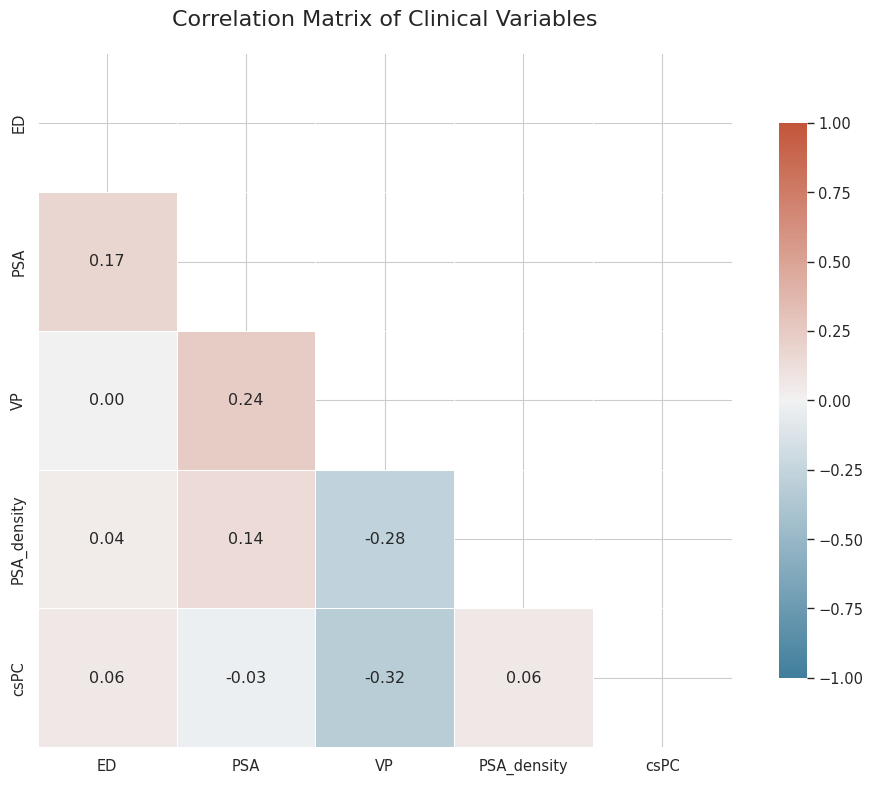

/tmp/ipykernel_173004/3534910629.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cspc_corr.values, y=cspc_corr.index, palette='RdBu_r')


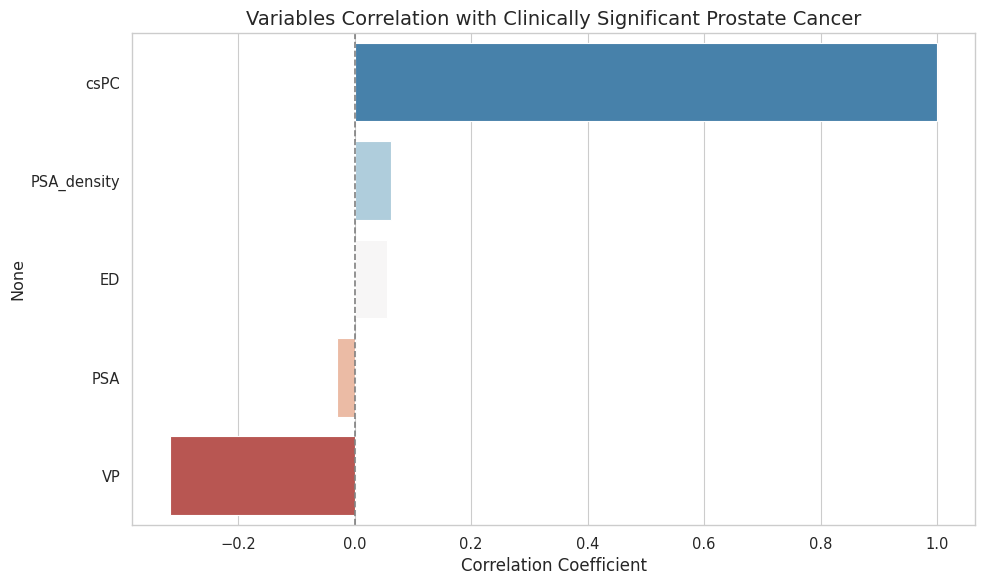

In [12]:
#Check Correlation
# Create a professional correlation matrix visualization
plt.figure(figsize=(10, 8))
corr = df_cleaned[["ED", "PSA", "VP", "PSA_density", "csPC"]].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Create a custom colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(
    corr, 
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

# Add titles and adjust layout
plt.title('Correlation Matrix of Clinical Variables', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Display the correlation with csPC specifically for clinical interpretation
cspc_corr = corr['csPC'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=cspc_corr.values, y=cspc_corr.index, palette='RdBu_r')
plt.title('Variables Correlation with Clinically Significant Prostate Cancer', fontsize=14)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.axvline(x=0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

In [9]:
# Cargar el archivo CSV
file_path = "/home/jaalzate/Files/training_df_variables_not_na.csv"
df = pd.read_csv(file_path)

variables = ["ED", "PSA", "VP", "PSA_density", "csPC"]
# variables = ["ED", "PSA", "VP", "PSA_density", "csPC","dep","PIR"]
df_filtered = df[variables].dropna()

lower_bound = df_filtered.quantile(0.01)
upper_bound = df_filtered.quantile(0.99)
df_cleaned = df_filtered[(df_filtered >= lower_bound) & (df_filtered <= upper_bound)].dropna()

In [10]:
df_cleaned.shape

(2525, 5)

,Feature,Test,p-value,p-value (adjusted),Significant,Statistic,Effect Size (Cohen's d),Mean (Negative),Mean (Positive),Median (Negative),Median (Positive),Std (Negative),Std (Positive)
2,VP,Mann-Whitney U test,2.507596e-114,1.003039e-113,True,1207465.0,0.854400,73.391114,42.887281,67.00000,36.000000,40.357098,29.369727
3,PSA_density,Mann-Whitney U test,5.529596e-62,2.211839e-61,True,488946.0,-0.222446,0.212090,0.346400,0.11653,0.196678,0.541115,0.669378
0,ED,Mann-Whitney U test,9.434456e-12,3.773782e-11,True,668041.5,-0.272444,66.339470,68.245930,66.00000,68.000000,6.991547,7.004680
1,PSA,Mann-Whitney U test,4.377712e-04,1.751085e-03,True,856615.5,0.099236,9.236038,8.665384,7.41500,7.270000,5.707428,5.800131


/tmp/ipykernel_173004/2268673806.py:155: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'F-value': anova_table['F'][0],
/tmp/ipykernel_173004/2268673806.py:156: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'p-value': anova_table['PR(>F)'][0],
/tmp/ipykernel_173004/2268673806.py:157: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'df_between': anova_table['df'][0],
/tmp/ipykernel_173004/2268673806.py:158: FutureWarning: Series.__getit

,Feature,F-value,p-value,df_between,df_within,p-value (adjusted),Significant
2,VP,458.175200,1.532692e-93,1.0,2523.0,6.130770e-93,True
0,ED,46.586918,1.093752e-11,1.0,2523.0,4.375008e-11,True
3,PSA_density,31.056953,2.771509e-08,1.0,2523.0,1.108604e-07,True
1,PSA,6.180873,1.297811e-02,1.0,2523.0,5.191243e-02,False


/tmp/ipykernel_173004/2268673806.py:191: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


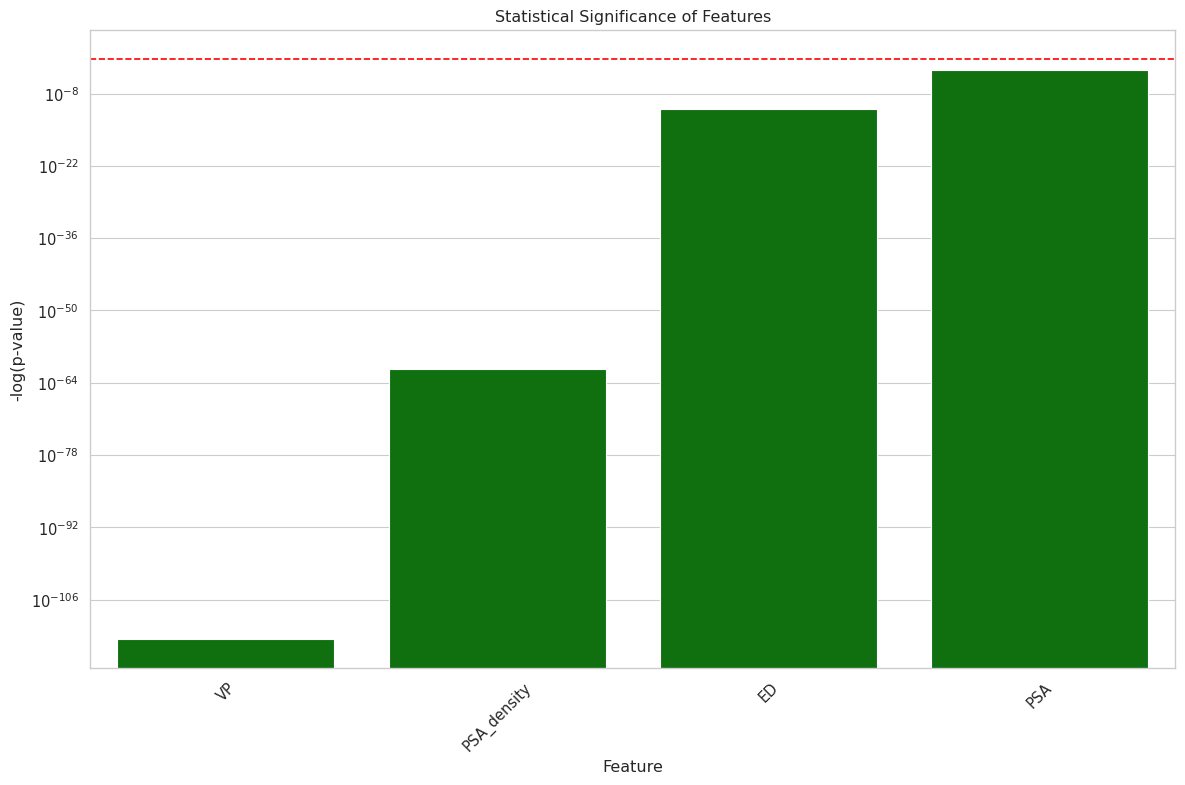

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, f_oneway
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from pingouin import compute_effsize

# Import necessary libraries
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm

def perform_statistical_tests(df, outcome_var='csPC', features=None, alpha=0.05):
    """
    Perform comprehensive statistical tests on dataframe variables
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame containing the data
    outcome_var : str
        Outcome variable (dependent variable, e.g., 'csPC')
    features : list or None
        List of feature variables to test. If None, all numeric columns except outcome_var are used
    alpha : float
        Significance level for tests
        
    Returns:
    --------
    DataFrame with statistical test results
    """
    # If features not specified, use all numeric columns except outcome variable
    if features is None:
        features = [col for col in df.select_dtypes(include=['float64', 'int64']).columns 
                   if col != outcome_var]
    
    # Prepare results storage
    results = []
    
    # Get groups
    group0 = df[df[outcome_var] == 0]
    group1 = df[df[outcome_var] == 1]
    
    # Test each feature
    for feature in features:
        result = {'Feature': feature}
        
        # Basic statistics
        result['Mean (Negative)'] = group0[feature].mean()
        result['Mean (Positive)'] = group1[feature].mean()
        result['Median (Negative)'] = group0[feature].median()
        result['Median (Positive)'] = group1[feature].median()
        result['Std (Negative)'] = group0[feature].std()
        result['Std (Positive)'] = group1[feature].std()
        
        # Calculate effect size
        effect_size = compute_effsize(
            group0[feature].values, 
            group1[feature].values, 
            eftype='cohen'
        )
        result['Effect Size (Cohen\'s d)'] = effect_size
        
        # Check normality
        _, p_norm_neg = shapiro(group0[feature].sample(min(5000, len(group0[feature]))).values)
        _, p_norm_pos = shapiro(group1[feature].sample(min(5000, len(group1[feature]))).values)
        
        # Test for equal variance
        _, p_var = stats.levene(group0[feature].dropna(), group1[feature].dropna())
        
        # Determine appropriate test
        if p_norm_neg > 0.05 and p_norm_pos > 0.05:  # Both are approximately normal
            if p_var > 0.05:  # Equal variances
                stat, p_value = ttest_ind(group0[feature].dropna(), group1[feature].dropna(), equal_var=True)
                test_name = "Student's t-test"
            else:  # Unequal variances
                stat, p_value = ttest_ind(group0[feature].dropna(), group1[feature].dropna(), equal_var=False)
                test_name = "Welch's t-test"
        else:  # At least one is not normal
            stat, p_value = mannwhitneyu(group0[feature].dropna(), group1[feature].dropna())
            test_name = "Mann-Whitney U test"
        
        result['Test'] = test_name
        result['p-value'] = p_value
        result['Statistic'] = stat
        
        results.append(result)
    
    # Create results dataframe
    results_df = pd.DataFrame(results)
    
    # Apply multiple testing correction
    if len(features) > 1:
        _, results_df['p-value (adjusted)'], _, _ = multipletests(
            results_df['p-value'], 
            alpha=alpha, 
            method='bonferroni'
        )
    else:
        results_df['p-value (adjusted)'] = results_df['p-value']
    
    # Add significance indicator
    results_df['Significant'] = results_df['p-value (adjusted)'] < alpha
    
    # Reorder columns for better readability
    column_order = [
        'Feature', 'Test', 'p-value', 'p-value (adjusted)', 'Significant', 
        'Statistic', 'Effect Size (Cohen\'s d)',
        'Mean (Negative)', 'Mean (Positive)', 
        'Median (Negative)', 'Median (Positive)',
        'Std (Negative)', 'Std (Positive)'
    ]
    
    return results_df[column_order].sort_values('p-value')

def perform_anova_for_features(df, outcome_var='csPC', features=None):
    """
    Perform ANOVA for each feature to test if it significantly differs between groups
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame containing the data
    outcome_var : str
        Outcome variable (dependent variable, e.g., 'csPC')
    features : list or None
        List of feature variables to test. If None, all numeric columns except outcome_var are used
        
    Returns:
    --------
    DataFrame with ANOVA results
    """
    if features is None:
        features = [col for col in df.select_dtypes(include=['float64', 'int64']).columns 
                   if col != outcome_var]
    
    anova_results = []
    
    for feature in features:
        # Create formula
        formula = f"{feature} ~ C({outcome_var})"
        
        # Fit model
        model = ols(formula, data=df).fit()
        
        # Perform ANOVA
        try:
            anova_table = sm.stats.anova_lm(model, typ=2)
            
            # Add results
            anova_results.append({
                'Feature': feature,
                'F-value': anova_table['F'][0],
                'p-value': anova_table['PR(>F)'][0],
                'df_between': anova_table['df'][0],
                'df_within': anova_table['df'][1]
            })
        except:
            print(f"Error performing ANOVA on {feature}. Skipping.")
    
    # Create and return DataFrame
    anova_df = pd.DataFrame(anova_results)
    
    # Apply multiple testing correction if needed
    if len(features) > 1:
        _, anova_df['p-value (adjusted)'], _, _ = multipletests(
            anova_df['p-value'], 
            alpha=0.05, 
            method='bonferroni'
        )
    else:
        anova_df['p-value (adjusted)'] = anova_df['p-value']
    
    # Add significance indicator
    anova_df['Significant'] = anova_df['p-value (adjusted)'] < 0.05
    
    return anova_df.sort_values('p-value')

# Run statistical tests
stat_results = perform_statistical_tests(df_cleaned, features=["ED", "PSA", "VP", "PSA_density"])
display(stat_results)

# Run ANOVA
anova_results = perform_anova_for_features(df_cleaned, features=["ED", "PSA", "VP", "PSA_density"])
display(anova_results)

# Create visualization of results
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Feature', 
    y='p-value', 
    data=stat_results,
    palette=['green' if x else 'red' for x in stat_results['Significant']]
)
plt.axhline(y=0.05, color='r', linestyle='--')
plt.yscale('log')
plt.ylabel('-log(p-value)')
plt.title('Statistical Significance of Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Separar características y variable objetivo
X = df_cleaned.drop(columns=["csPC"])
y = df_cleaned["csPC"]
subjects = df.iloc[X.index]['subject'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=subjects))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
# Normalizar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, precision_recall_curve, auc, confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy import stats
import matplotlib.pyplot as plt

# Set professional plotting style
colors = {"main": "#1f77b4", "secondary": "#ff7f0e", "highlight": "#d62728"}

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Get predictions
y_pred = lr_model.predict(X_test_scaled)
y_pred_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC AUC': roc_auc_score(y_test, y_pred_prob)
}

# 1. Model Performance Metrics
plt.figure(figsize=(8, 6))
metrics_df = pd.DataFrame({'Metric': list(metrics.keys()), 'Value': list(metrics.values())})
bars = sns.barplot(x='Value', y='Metric', data=metrics_df, palette='Blues_d')
plt.xlim(0, 1)
plt.title('Logistic Regression Performance Metrics', fontsize=14, fontweight='bold')
plt.xlabel('Score', fontsize=12)
plt.ylabel('')
for i, v in enumerate(metrics.values()):
    plt.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('lr_performance_metrics.pdf')
plt.close()

# 2. Confusion Matrix with counts
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Negative', 'Positive'])
plt.yticks([0.5, 1.5], ['Negative', 'Positive'])
plt.tight_layout()
plt.savefig('lr_confusion_matrix_counts.pdf')
plt.close()

# 3. Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues")
plt.title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Negative', 'Positive'])
plt.yticks([0.5, 1.5], ['Negative', 'Positive'])
plt.tight_layout()
plt.savefig('lr_confusion_matrix_normalized.pdf')
plt.close()

# 4. ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color=colors["main"], lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('lr_roc_curve.pdf')
plt.close()

# 5. Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
plt.plot(recall, precision, color=colors["secondary"], lw=2,
         label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig('lr_precision_recall_curve.pdf')
plt.close()

# 6. Calibration Curve
plt.figure(figsize=(8, 6))
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, color=colors["highlight"])
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Calibration Plot', fontsize=14, fontweight='bold')
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.tight_layout()
plt.savefig('lr_calibration_curve.pdf')
plt.close()

# 7. Feature Importance
plt.figure(figsize=(10, 8))
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(lr_model.coef_[0]),
    'Direction': np.where(lr_model.coef_[0] > 0, 'Positive', 'Negative'),
    'Coefficient': lr_model.coef_[0]
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
palette = [colors["main"] if x == 'Positive' else colors["highlight"] for x in feature_importance['Direction']]
bars = sns.barplot(x='Importance', y='Feature', hue='Direction', data=feature_importance, 
                   palette=palette, dodge=False)
plt.title('Feature Importance in Logistic Regression Model', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
for i, v in enumerate(feature_importance['Coefficient']):
    plt.text(feature_importance['Importance'].iloc[i] + 0.01, i, f'β = {v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('lr_feature_importance.pdf')
plt.close()

# 8. Probability Distribution
plt.figure(figsize=(8, 6))
sns.histplot(data=pd.DataFrame({
    'Probability': y_pred_prob,
    'Actual': y_test.values
}), x='Probability', hue='Actual', bins=20, element='step', stat='density', common_norm=False)
plt.title('Predicted Probability Distribution by Class', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability of csPC', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.7, label='Decision Threshold')
plt.legend(title='Actual csPC Status', loc='upper right')
plt.tight_layout()
plt.savefig('lr_probability_distribution.pdf')
plt.close()

# 9. Classification Report
plt.figure(figsize=(8, 6))
report = classification_report(y_test, y_pred, output_dict=True)
report_text = (f"Classification Report:\n\n"
               f"Precision (Positive): {report['1.0']['precision']:.3f}\n"
               f"Recall (Positive): {report['1.0']['recall']:.3f}\n"
               f"F1-score (Positive): {report['1.0']['f1-score']:.3f}\n\n"
               f"Precision (Negative): {report['0.0']['precision']:.3f}\n"
               f"Recall (Negative): {report['0.0']['recall']:.3f}\n"
               f"F1-score (Negative): {report['0.0']['f1-score']:.3f}\n\n"
               f"Accuracy: {report['accuracy']:.3f}")
plt.text(0.5, 0.5, report_text, ha='center', va='center', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig('lr_classification_report.pdf')
plt.close()

# 10. Odds Ratios with Confidence Intervals
plt.figure(figsize=(10, 6))
odds_ratios = np.exp(lr_model.coef_[0])
feature_names = X.columns
n_samples = len(X_train_scaled)
p = len(feature_names)
dof = n_samples - p - 1
t_val = stats.t.ppf(0.975, dof)
std_err = np.std(X_train_scaled, axis=0) / np.sqrt(n_samples)
conf_intervals = t_val * std_err * np.abs(lr_model.coef_[0])
or_df = pd.DataFrame({
    'Feature': feature_names,
    'Odds Ratio': odds_ratios,
    'CI Lower': np.exp(lr_model.coef_[0] - conf_intervals),
    'CI Upper': np.exp(lr_model.coef_[0] + conf_intervals)
})
or_df = or_df.sort_values('Odds Ratio', ascending=False)
plt.errorbar(
    x=or_df['Odds Ratio'], 
    y=range(len(or_df)), 
    xerr=[or_df['Odds Ratio'] - or_df['CI Lower'], or_df['CI Upper'] - or_df['Odds Ratio']],
    fmt='o', 
    capsize=5,
    color=colors["main"],
    ecolor=colors["secondary"],
    markersize=10
)
plt.axvline(x=1, color='gray', linestyle='--', alpha=0.7)
plt.yticks(range(len(or_df)), or_df['Feature'])
plt.xscale('log')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.title('Odds Ratios with 95% Confidence Intervals', fontsize=16, fontweight='bold')
plt.xlabel('Odds Ratio (log scale)', fontsize=14)
plt.ylabel('Feature', fontsize=14)
for i, (_, row) in enumerate(or_df.iterrows()):
    plt.text(
        row['Odds Ratio'], 
        i, 
        f" {row['Odds Ratio']:.3f} ({row['CI Lower']:.3f}-{row['CI Upper']:.3f})",
        va='center',
        fontsize=10
    )
plt.tight_layout()
plt.savefig('lr_odds_ratios.pdf')
plt.close()


/tmp/ipykernel_73240/2694215790.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Value', y='Metric', data=metrics_df, palette='Blues_d')
/tmp/ipykernel_73240/2694215790.py:126: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  bars = sns.barplot(x='Importance', y='Feature', hue='Direction', data=feature_importance,


In [15]:
df_cleaned.describe()

,ED,PSA,VP,PSA_density,csPC
count,2525.000000,2525.000000,2525.000000,2525.000000,2525.000000
mean,67.220594,8.972294,59.292907,0.274165,0.462178
std,7.060530,5.756355,38.800946,0.607372,0.498666
min,50.000000,0.400000,0.950000,0.011880,0.000000
25%,62.000000,5.550000,31.590000,0.094518,0.000000
50%,68.000000,7.360000,52.000000,0.146392,0.000000
75%,72.000000,10.500000,77.000000,0.251383,1.000000
max,84.000000,43.730000,343.000000,8.515789,1.000000


In [27]:
# Modelos de Machine Learning
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.74      0.67      0.70       281
         1.0       0.65      0.73      0.69       241

    accuracy                           0.69       522
   macro avg       0.69      0.70      0.69       522
weighted avg       0.70      0.69      0.69       522

Classification Report for Random Forest:
              precision    recall  f1-score   support

         0.0       0.68      0.64      0.66       281
         1.0       0.61      0.65      0.63       241

    accuracy                           0.65       522
   macro avg       0.65      0.65      0.64       522
weighted avg       0.65      0.65      0.65       522

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

         0.0       0.71      0.69      0.70       281
         1.0       0.65      0.67      0.66       241

    accuracy                           0.68      

/projects/ceib/python_enviroments/monai/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Classification Report for AdaBoost:
              precision    recall  f1-score   support

         0.0       0.69      0.74      0.71       281
         1.0       0.67      0.61      0.64       241

    accuracy                           0.68       522
   macro avg       0.68      0.68      0.68       522
weighted avg       0.68      0.68      0.68       522

Classification Report for SVM:
              precision    recall  f1-score   support

         0.0       0.72      0.70      0.71       281
         1.0       0.66      0.68      0.67       241

    accuracy                           0.69       522
   macro avg       0.69      0.69      0.69       522
weighted avg       0.69      0.69      0.69       522

Classification Report for KNN:
              precision    recall  f1-score   support

         0.0       0.63      0.61      0.62       281
         1.0       0.56      0.59      0.57       241

    accuracy                           0.60       522
   macro avg       0.60      0

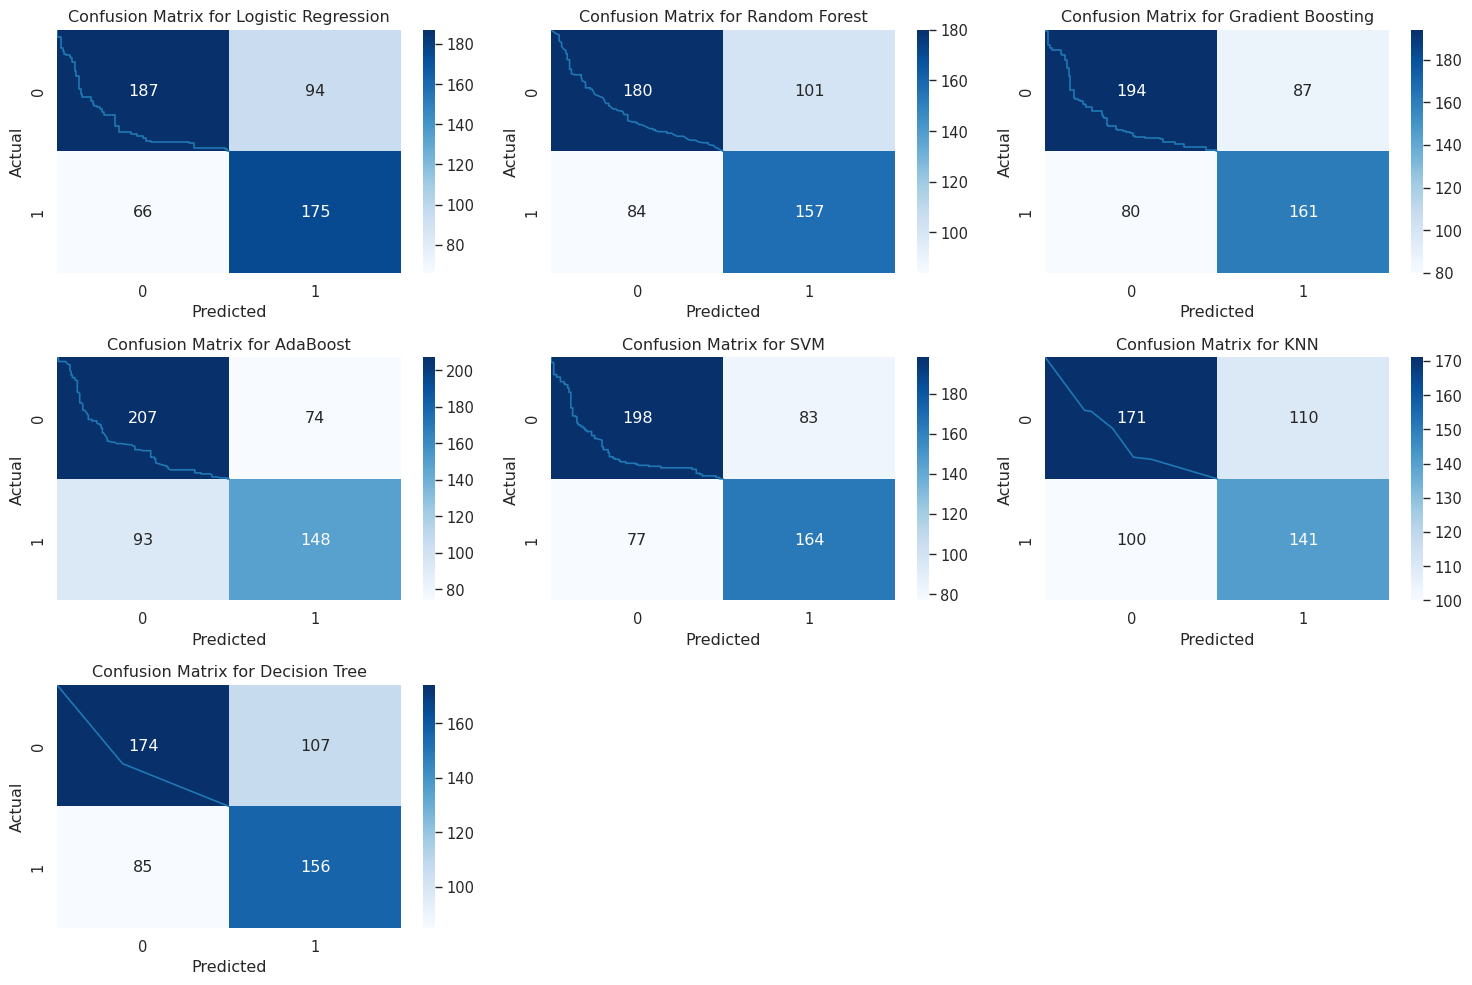

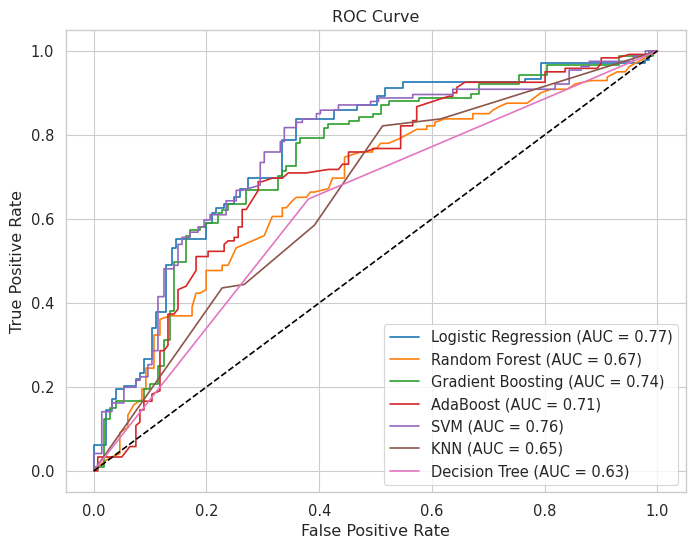

In [28]:
# Entrenar y evaluar modelos
results = []
plt.figure(figsize=(15, 10))
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}")
    cm = confusion_matrix(y_test, y_pred)
    
    plt.subplot(3, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    results.append({"Model": name, "Accuracy": accuracy, "F1 Score": f1, "ROC AUC": roc_auc})

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.72      0.76      0.74       162
         1.0       0.56      0.52      0.54        97

    accuracy                           0.67       259
   macro avg       0.64      0.64      0.64       259
weighted avg       0.66      0.67      0.66       259

Classification Report for Random Forest:
              precision    recall  f1-score   support

         0.0       0.74      0.78      0.76       162
         1.0       0.60      0.55      0.57        97

    accuracy                           0.69       259
   macro avg       0.67      0.67      0.67       259
weighted avg       0.69      0.69      0.69       259

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

         0.0       0.78      0.78      0.78       162
         1.0       0.63      0.64      0.64        97

    accuracy                           0.73      

/projects/ceib/python_enviroments/monai/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Classification Report for AdaBoost:
              precision    recall  f1-score   support

         0.0       0.81      0.79      0.80       162
         1.0       0.66      0.68      0.67        97

    accuracy                           0.75       259
   macro avg       0.73      0.74      0.73       259
weighted avg       0.75      0.75      0.75       259

Classification Report for SVM:
              precision    recall  f1-score   support

         0.0       0.82      0.78      0.80       162
         1.0       0.66      0.72      0.69        97

    accuracy                           0.76       259
   macro avg       0.74      0.75      0.74       259
weighted avg       0.76      0.76      0.76       259

Classification Report for KNN:
              precision    recall  f1-score   support

         0.0       0.74      0.75      0.74       162
         1.0       0.57      0.56      0.56        97

    accuracy                           0.68       259
   macro avg       0.65      0

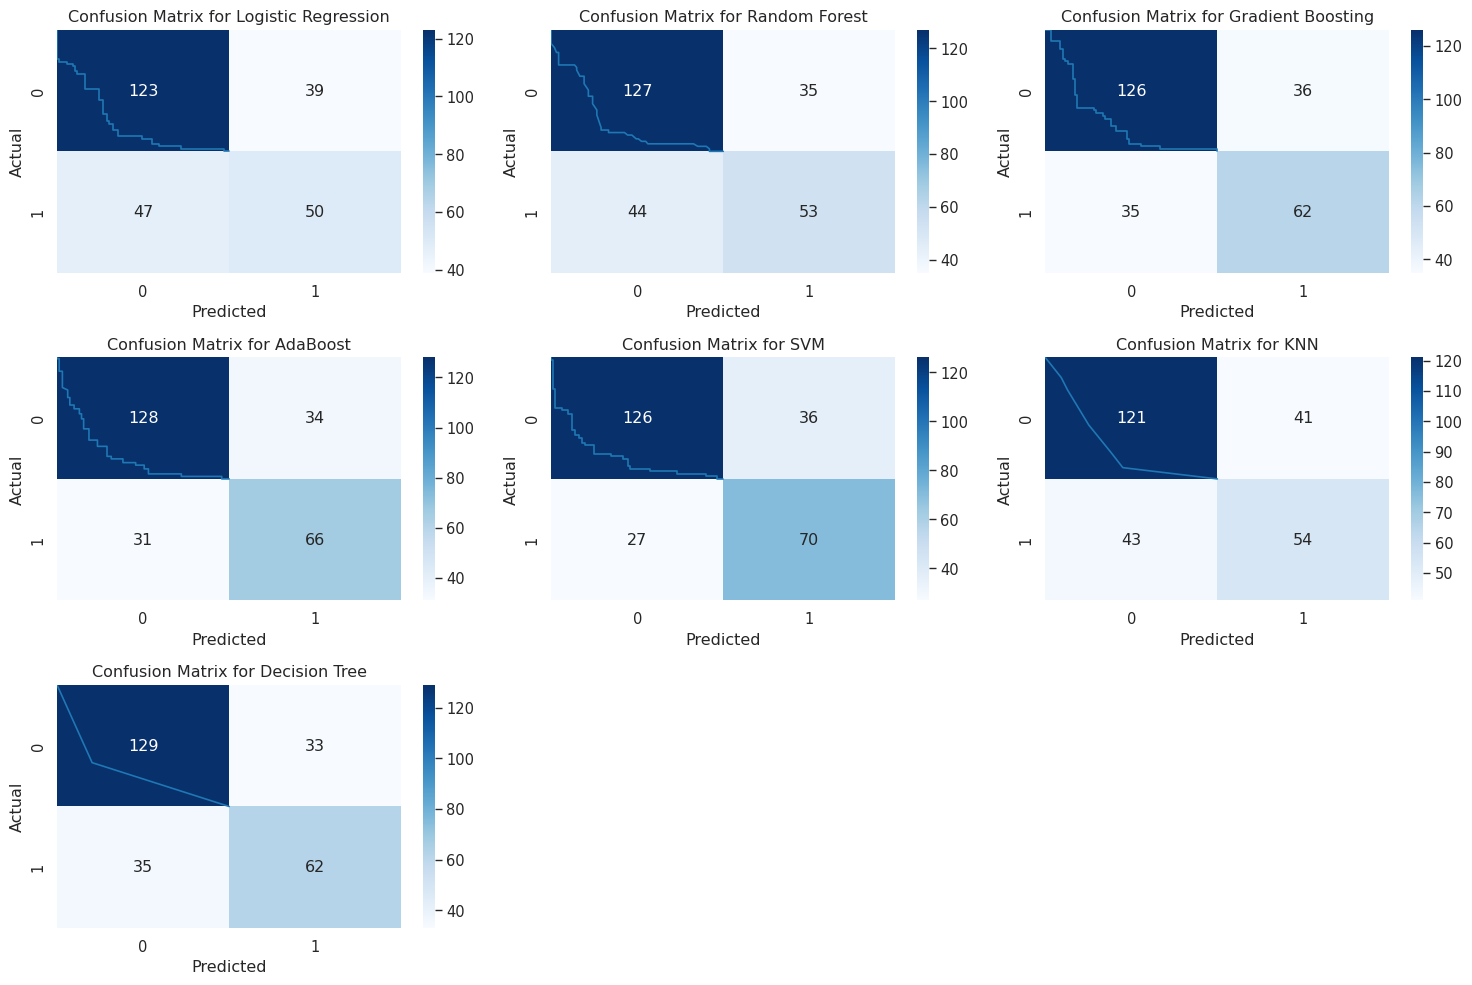

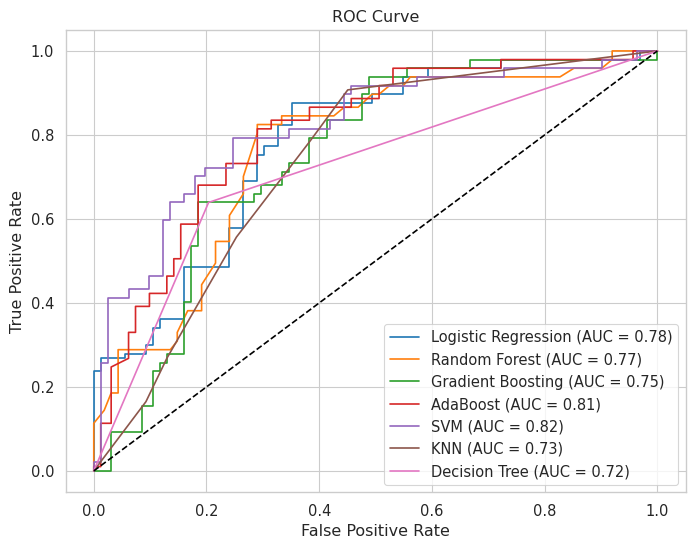

In [15]:
# Entrenar y evaluar modelos
results = []
plt.figure(figsize=(15, 10))
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}")
    cm = confusion_matrix(y_test, y_pred)
    
    plt.subplot(3, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    results.append({"Model": name, "Accuracy": accuracy, "F1 Score": f1, "ROC AUC": roc_auc})

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)

## Cross Validation

In [16]:
X

,ED,PSA,VP,PSA_density,dep,PIR
3,60.0,5.15,44.928,0.114628,17.0,4.0
4,60.0,5.15,44.928,0.114628,17.0,4.0
5,60.0,5.15,44.928,0.114628,17.0,4.0
12,62.0,7.07,100.100,0.070629,5.0,4.0
13,62.0,7.07,100.100,0.070629,5.0,4.0
...,...,...,...,...,...,...
2659,63.0,7.60,70.000,0.108571,7.0,4.0
2660,63.0,7.60,70.000,0.108571,7.0,4.0
2661,72.0,4.26,65.000,0.065538,7.0,5.0
2662,72.0,4.26,65.000,0.065538,7.0,5.0


In [17]:
results = []
gkf = GroupKFold(n_splits=5)
results = []
averages = []
for name, model in models.items():
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=subjects)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred
        
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)
        
        print(f"{name} - Fold {fold+1}: Accuracy = {accuracy:.4f}, F1 Score = {f1:.4f}, ROC AUC = {roc_auc:.4f}")
        
        fold_results.append({"Fold": fold+1, "Model": name, "Accuracy": accuracy, "F1 Score": f1, "ROC AUC": roc_auc})
    
    results.extend(fold_results)
    avg_results = {
        "Model": name,
        "Mean Accuracy": np.mean([r["Accuracy"] for r in fold_results]),
        "Std Accuracy": np.std([r["Accuracy"] for r in fold_results]),
        "Mean F1 Score": np.mean([r["F1 Score"] for r in fold_results]),
        "Std F1 Score": np.std([r["F1 Score"] for r in fold_results]),
        "Mean ROC AUC": np.mean([r["ROC AUC"] for r in fold_results]),
        "Std ROC AUC": np.std([r["ROC AUC"] for r in fold_results])
    }
    averages.append(avg_results)

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)
averages_df = pd.DataFrame(averages)

# Mostrar resultados
display(results_df)
display(averages_df)

Logistic Regression - Fold 1: Accuracy = 0.6898, F1 Score = 0.5914, ROC AUC = 0.7550
Logistic Regression - Fold 2: Accuracy = 0.7090, F1 Score = 0.6432, ROC AUC = 0.7655
Logistic Regression - Fold 3: Accuracy = 0.5943, F1 Score = 0.4870, ROC AUC = 0.6572
Logistic Regression - Fold 4: Accuracy = 0.7131, F1 Score = 0.5930, ROC AUC = 0.7912
Logistic Regression - Fold 5: Accuracy = 0.6885, F1 Score = 0.5128, ROC AUC = 0.7810
Random Forest - Fold 1: Accuracy = 0.7224, F1 Score = 0.6000, ROC AUC = 0.7557
Random Forest - Fold 2: Accuracy = 0.6639, F1 Score = 0.5816, ROC AUC = 0.7300
Random Forest - Fold 3: Accuracy = 0.5451, F1 Score = 0.4064, ROC AUC = 0.6000
Random Forest - Fold 4: Accuracy = 0.7049, F1 Score = 0.5714, ROC AUC = 0.7535
Random Forest - Fold 5: Accuracy = 0.7131, F1 Score = 0.6023, ROC AUC = 0.7744
Gradient Boosting - Fold 1: Accuracy = 0.6531, F1 Score = 0.5251, ROC AUC = 0.7337
Gradient Boosting - Fold 2: Accuracy = 0.6352, F1 Score = 0.5482, ROC AUC = 0.6848
Gradient Boost

/projects/ceib/python_enviroments/monai/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/projects/ceib/python_enviroments/monai/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost - Fold 1: Accuracy = 0.6857, F1 Score = 0.5882, ROC AUC = 0.7127
AdaBoost - Fold 2: Accuracy = 0.7090, F1 Score = 0.6758, ROC AUC = 0.7173
AdaBoost - Fold 3: Accuracy = 0.5984, F1 Score = 0.5243, ROC AUC = 0.6043


/projects/ceib/python_enviroments/monai/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/projects/ceib/python_enviroments/monai/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost - Fold 4: Accuracy = 0.7172, F1 Score = 0.6462, ROC AUC = 0.7465
AdaBoost - Fold 5: Accuracy = 0.6762, F1 Score = 0.5380, ROC AUC = 0.7556


/projects/ceib/python_enviroments/monai/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


SVM - Fold 1: Accuracy = 0.7020, F1 Score = 0.5780, ROC AUC = 0.7543
SVM - Fold 2: Accuracy = 0.7500, F1 Score = 0.6839, ROC AUC = 0.7286
SVM - Fold 3: Accuracy = 0.6393, F1 Score = 0.5644, ROC AUC = 0.6727
SVM - Fold 4: Accuracy = 0.7664, F1 Score = 0.6851, ROC AUC = 0.7858
SVM - Fold 5: Accuracy = 0.7008, F1 Score = 0.5780, ROC AUC = 0.7596
KNN - Fold 1: Accuracy = 0.6163, F1 Score = 0.4535, ROC AUC = 0.6341
KNN - Fold 2: Accuracy = 0.5902, F1 Score = 0.5370, ROC AUC = 0.6453
KNN - Fold 3: Accuracy = 0.5697, F1 Score = 0.5291, ROC AUC = 0.6190
KNN - Fold 4: Accuracy = 0.7172, F1 Score = 0.6145, ROC AUC = 0.7567
KNN - Fold 5: Accuracy = 0.6025, F1 Score = 0.4699, ROC AUC = 0.6414
Decision Tree - Fold 1: Accuracy = 0.5918, F1 Score = 0.4253, ROC AUC = 0.5542
Decision Tree - Fold 2: Accuracy = 0.5861, F1 Score = 0.5025, ROC AUC = 0.5756
Decision Tree - Fold 3: Accuracy = 0.5082, F1 Score = 0.3478, ROC AUC = 0.4853
Decision Tree - Fold 4: Accuracy = 0.6680, F1 Score = 0.5970, ROC AUC = 0

,Fold,Model,Accuracy,F1 Score,ROC AUC
0,1,Logistic Regression,0.689796,0.591398,0.755023
1,2,Logistic Regression,0.709016,0.643216,0.765495
2,3,Logistic Regression,0.594262,0.487047,0.657207
3,4,Logistic Regression,0.713115,0.593023,0.791159
4,5,Logistic Regression,0.688525,0.512821,0.781031
5,1,Random Forest,0.722449,0.600000,0.755730
6,2,Random Forest,0.663934,0.581633,0.730001
7,3,Random Forest,0.545082,0.406417,0.600041
8,4,Random Forest,0.704918,0.571429,0.753544
9,5,Random Forest,0.713115,0.602273,0.774403


,Model,Mean Accuracy,Std Accuracy,Mean F1 Score,Std F1 Score,Mean ROC AUC,Std ROC AUC
0,Logistic Regression,0.678943,0.043480,0.565501,0.057268,0.749983,0.048027
1,Random Forest,0.669900,0.065529,0.552350,0.073866,0.722744,0.062951
2,Gradient Boosting,0.644547,0.032897,0.520281,0.050923,0.715709,0.039798
3,AdaBoost,0.677307,0.042196,0.594494,0.059059,0.707299,0.054039
4,SVM,0.711720,0.044509,0.617889,0.054626,0.740205,0.038341
5,KNN,0.619167,0.051364,0.520829,0.056982,0.659312,0.049516
6,Decision Tree,0.607712,0.063478,0.487513,0.091212,0.592639,0.073480


/tmp/ipykernel_173004/922906973.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


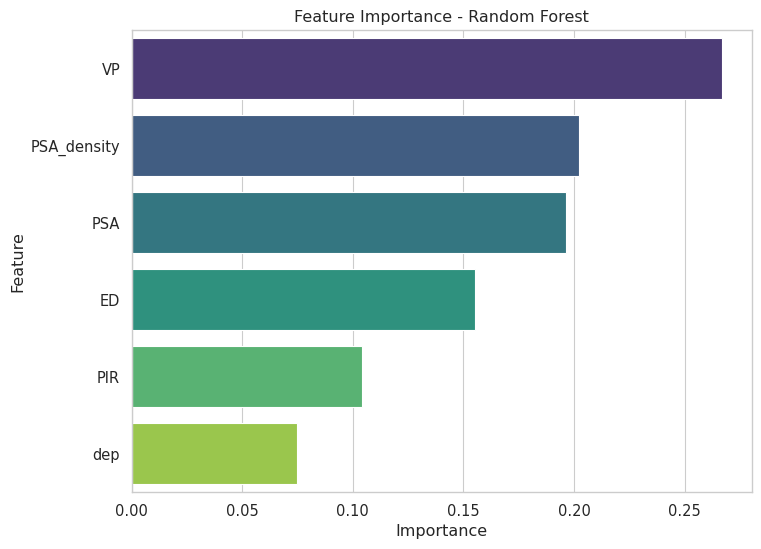

In [18]:
# Analizar importancia de características con Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train_scaled, y_train)
feature_importances = rf_model.feature_importances_

# Crear un dataframe con los resultados
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Graficar importancia de características
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [61]:
# Definir modelo de red neuronal en PyTorch
class SimpleNN(nn.Module):
    def __init__(self, in_num_features=4, n_classes=2, feature_size=48):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(in_num_features, feature_size)
        self.fc2 = nn.Linear(feature_size, feature_size)
        self.fc3 = nn.Linear(feature_size, feature_size)
        self.fc4 = nn.Linear(feature_size, feature_size)
        self.fc = nn.Linear(feature_size, feature_size)
        self.out_class = nn.Linear(feature_size, n_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = torch.relu(self.fc(x))
        x = self.out_class(x)
        return x


In [62]:
# Convertir datos a tensores para PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Crear DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) 

In [63]:
# Inicializar y entrenar la red neuronal
model_nn = SimpleNN(in_num_features=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_nn.parameters(), lr=0.001)

num_epochs = 20
for epoch in range(num_epochs):
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_nn(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 1/20, Loss: 0.6537
Epoch 2/20, Loss: 0.6268
Epoch 3/20, Loss: 0.6402
Epoch 4/20, Loss: 0.6564
Epoch 5/20, Loss: 0.5733
Epoch 6/20, Loss: 0.4781
Epoch 7/20, Loss: 0.4892
Epoch 8/20, Loss: 0.5774
Epoch 9/20, Loss: 0.4534
Epoch 10/20, Loss: 0.5651
Epoch 11/20, Loss: 0.4035
Epoch 12/20, Loss: 0.5164
Epoch 13/20, Loss: 0.6327
Epoch 14/20, Loss: 0.4433
Epoch 15/20, Loss: 0.6376
Epoch 16/20, Loss: 0.6541
Epoch 17/20, Loss: 0.5756
Epoch 18/20, Loss: 0.5440
Epoch 19/20, Loss: 0.4079
Epoch 20/20, Loss: 0.6052


Neural Network Test Accuracy: 0.7069


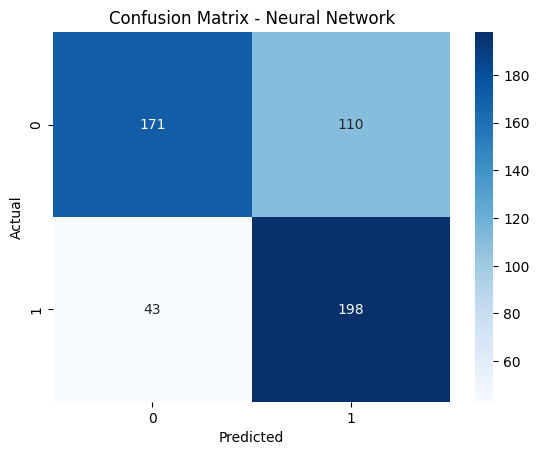

Classification Report - Neural Network:
               precision    recall  f1-score   support

           0       0.80      0.61      0.69       281
           1       0.64      0.82      0.72       241

    accuracy                           0.71       522
   macro avg       0.72      0.72      0.71       522
weighted avg       0.73      0.71      0.70       522



In [64]:
# Evaluación en test set
model_nn.eval()
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model_nn(batch_x)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(batch_y.numpy())
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

accuracy_nn = correct / total
print(f"Neural Network Test Accuracy: {accuracy_nn:.4f}")

# Matriz de confusión para la red neuronal
cm_nn = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report - Neural Network:\n", classification_report(all_labels, all_preds))